In [1]:
### A) نظرة عامة على البيانات:
#  Q1:** عدد الصفوف/الأعمدة، 5 عينات، أسماء الأعمدة
#  Q2:** شرح كل عمود (المعنى، النوع المتوقع، قاعدة أساسية)
#  Q3:** فحص أنواع البيانات وتحديد المشاكل

### B) جودة البيانات: - **Q4:** تقرير القيم المفقودة (العدد والنسبة)
#  Q5:** خطة التعامل مع القيم المفقودة (لكل عمود: الإجراء + السبب)
#  Q6:** فحص الصفوف المكررة
#  Q7:** فحص المفاتيح المكررة (إن وجد عمود ID)
#  Q8:** فحص القيم غير المنطقية (مبالغ سالبة، تواريخ مستقبلية...)
#  Q9:** نظافة التصنيفات (أخطاء إملائية، حالة الأحرف، مسافات زائدة)

### C) التحليل الأحادي:
#  Q10:** الإحصاءات الأساسية (mean, median, std, min, max)
#  Q11:** توزيعات الأعمدة الرقمية (Histograms + تحديد الانحراف)
#  Q12:** القيم المتطرفة (Boxplots + إجراء مقترح)
#  Q13:** ملخص التصنيفات (أكثر 10 قيم تكراراً)
#  Q14:** التصنيفات النادرة (أقل من 3%) + قرار الدمج أو الإبقاء

### D) العلاقات:
#  Q15:** مصفوفة الارتباط + أقوى 5 علاقات
#  Q16:** Scatter plots لأقوى الأزواج
#  Q17:** تأثير التصنيف على القيم الرقمية (group mean/median)
#  Q18:** علاقة تصنيف ↔ تصنيف (Crosstab)
#  Q19:** خريطة حرارية للارتباطات (Heatmap)

In [2]:
# ==============================
# 1- Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving EDA sheet 2.xlsx to EDA sheet 2.xlsx


In [4]:
# ==============================
# 2- Load Dataset
# ==============================

df = pd.read_excel("EDA sheet 2.xlsx")

In [5]:
dfc1 = df.copy()

In [6]:
# ==============================
# 3- Data Overview
# ==============================

In [7]:
#  Q1:** عدد الصفوف/الأعمدة، 5 عينات، أسماء الأعمدة

In [8]:
print("Shape of dataset:")
dfc1.shape


Shape of dataset:


(1000, 48)

In [9]:
print("\nColumns:")
dfc1.columns


Columns:


Index(['StudentID', 'StudentFullName', 'FirstName', 'LastName', 'StudentEmail',
       'StudentPhone', 'Gender', 'DateOfBirth', 'CurrentAge', 'BirthYear',
       'UniversityStartDate', 'EnrollmentYear', 'CurrentStudentStatus',
       'ProgramID', 'ProgramName', 'DegreeLevel', 'TotalCreditsRequired',
       'DepartmentID', 'DepartmentName', 'HeadOfDepartment',
       'NumberOfUniqueCoursesTaken', 'TotalEnrollmentAttempts',
       'TotalSectionsAttended', 'TotalInstructors', 'TotalSemestersAttended',
       'NumberOfGradedCourses', 'GPA', 'TotalGradePoints',
       'HighestGradeLetter', 'LowestGradeLetter', 'Count_A', 'Count_A_minus',
       'Count_B_plus', 'Count_B', 'Count_B_minus', 'Count_C_plus', 'Count_C',
       'Count_C_minus', 'Count_D', 'Count_F', 'NumberOfPassedCourses',
       'NumberOfFailedCourses', 'SuccessRatePercentage',
       'FirstCourseEnrollmentDate', 'LastCourseEnrollmentDate',
       'FirstSemesterAttended', 'LastSemesterAttended', 'AcademicActiveDays'],
      dtyp

In [10]:
# =============================================================
# Q2: شرح الأعمدة (المعنى | النوع | القاعدة)
# =============================================================

# --- Student Identity ---
# StudentID          : معرّف فريد للطالب              | int     | Unique, Not Null
# StudentFullName    : الاسم الكامل                   | str     | = FirstName + LastName
# FirstName          : الاسم الأول                    | str     | Not Null
# LastName           : اسم العائلة                    | str     | Not Null
# StudentEmail       : البريد الجامعي                 | str     | Unique
# StudentPhone       : رقم الهاتف                     | str
# --- Demographics ---
# Gender             : الجنس                          | str     | Male / Female فقط
# DateOfBirth        : تاريخ الميلاد                  | date
# CurrentAge         : العمر الحالي                   | int
# BirthYear          : سنة الميلاد                    | int

# --- Enrollment ---
# UniversityStartDate: تاريخ الالتحاق بالجامعة        | date    | بعد DateOfBirth بـ 16+ سنة
# EnrollmentYear     : سنة التسجيل                    | int     | مشتق من UniversityStartDate
# CurrentStudentStatus: الحالة الأكاديمية             | str     | Active / Graduated / Suspended

# --- Program ---
# ProgramID          : معرّف البرنامج                 | int     | 1 إلى 21
# ProgramName        : اسم البرنامج                   | str     | DegreeLevel + DepartmentName
# DegreeLevel        : مستوى الدرجة                   | str     | Bachelor / Master / PhD
# TotalCreditsRequired: الساعات المطلوبة للتخرج       | int     | 36=Master, 60=PhD, 120=Bachelor
# DepartmentID       : معرّف القسم                    | int     | 1 إلى 7
# DepartmentName     : اسم القسم                      | str     |   سبع أقسام ثابتة
# HeadOfDepartment   : رئيس القسم                     | str     | ثابت لكل DepartmentID

# --- Academic Activity ---
# NumberOfUniqueCoursesTaken : مقررات فريدة سُجِّل فيها  | int  | <= TotalEnrollmentAttempts
# TotalEnrollmentAttempts    : كل محاولات التسجيل        | int  | >= NumberOfUniqueCoursesTaken
# TotalSectionsAttended      : شعب دراسية حُضِرت         | int  | = TotalEnrollmentAttempts
# TotalInstructors           : عدد الأساتذة المختلفين    | int  | >= 1
# TotalSemestersAttended     : فصول دراسية حُضِرت        | int  | 1 أو 2 أو 3 فقط

# --- Grades ---
# NumberOfGradedCourses : مقررات مُقيَّمة              | int     | = Passed + Failed
# GPA                   : المعدل التراكمي              | float   | 0.0 – 4.0, Null إذا لا يوجد تقييم
# TotalGradePoints      : إجمالي نقاط الدرجات         | float   | GPA = TotalGradePoints / GradedCourses
# HighestGradeLetter    : أعلى درجة حرفية              | str     | Null إذا لا يوجد تقييم
# LowestGradeLetter     : أدنى درجة حرفية              | str     | Null إذا لا يوجد تقييم
# Count_A               : عدد مرات الحصول على A        | int     | >= 0
# Count_A_minus         : عدد مرات الحصول على A-       | int     | القيم = 0 → عمود ثابت
# Count_B_plus          : عدد مرات الحصول على B+       | int     | >= 0
# Count_B               : عدد مرات الحصول على B        | int     | >= 0
# Count_B_minus         : عدد مرات الحصول على B-       | int     |  كل القيم = 0 → عمود ثابت
# Count_C_plus          : عدد مرات الحصول على C+       | int     | >= 0
# Count_C               : عدد مرات الحصول على C        | int     | >= 0
# Count_C_minus         : عدد مرات الحصول على C-       | int     |  كل القيم = 0 → عمود ثابت
# Count_D               : عدد مرات الحصول على D        | int     | >= 0
# Count_F               : عدد مرات الرسوب              | int     | = NumberOfFailedCourses

# --- Pass / Fail ---
# NumberOfPassedCourses  : مقررات ناجح فيها            | int     | = GradedCourses - FailedCourses
# NumberOfFailedCourses  : مقررات راسب فيها            | int     | = Count_F
# SuccessRatePercentage  : نسبة النجاح                 | float   | (Passed / Graded) * 100, بين 0–100

# --- Dates & Semesters ---
# FirstCourseEnrollmentDate : تاريخ أول تسجيل في مقرر | date    | قبل LastCourseEnrollmentDate
# LastCourseEnrollmentDate  : تاريخ آخر تسجيل في مقرر | date    | بعد FirstCourseEnrollmentDate
# FirstSemesterAttended     : أول فصل دراسي            | str     | صيغة: 'Fall/Spring YYYY'
# LastSemesterAttended      : آخر فصل دراسي            | str     | بعد أو يساوي FirstSemester
# AcademicActiveDays        : أيام النشاط الأكاديمي    | int     | > 0


In [11]:
print("\nData types:")
dfc1.info()


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   StudentID                   1000 non-null   int64         
 1   StudentFullName             1000 non-null   object        
 2   FirstName                   1000 non-null   object        
 3   LastName                    1000 non-null   object        
 4   StudentEmail                1000 non-null   object        
 5   StudentPhone                1000 non-null   object        
 6   Gender                      1000 non-null   object        
 7   DateOfBirth                 1000 non-null   datetime64[ns]
 8   CurrentAge                  1000 non-null   int64         
 9   BirthYear                   1000 non-null   int64         
 10  UniversityStartDate         1000 non-null   datetime64[ns]
 11  EnrollmentYear              1000 non-null   

In [12]:
# :** الإحصاءات الأساسية (mean, median, std, min, max)

In [13]:
print("\nStatistical Summary:")
dfc1.describe()


Statistical Summary:


,StudentID,DateOfBirth,CurrentAge,BirthYear,UniversityStartDate,EnrollmentYear,ProgramID,TotalCreditsRequired,DepartmentID,NumberOfUniqueCoursesTaken,...,Count_C,Count_C_minus,Count_D,Count_F,NumberOfPassedCourses,NumberOfFailedCourses,SuccessRatePercentage,FirstCourseEnrollmentDate,LastCourseEnrollmentDate,AcademicActiveDays
count,1000.000000,1000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.00000
mean,500.500000,2001-09-23 11:52:47.999999872,24.757000,2001.243000,2024-02-11 03:01:26.400000256,2023.614000,10.976000,71.244000,3.981000,7.868000,...,0.956000,0.0,0.952000,0.969000,5.786000,0.969000,85.301968,2025-04-20 08:32:16.880999936,2026-01-17 08:11:44.549999872,271.99400
min,1.000000,1995-03-06 00:00:00,18.000000,1995.000000,2022-03-05 00:00:00,2022.000000,1.000000,36.000000,1.000000,3.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-03-05 09:34:53,2025-05-27 17:11:24,32.00000
25%,250.750000,1998-06-16 06:00:00,21.000000,1998.000000,2023-02-10 18:00:00,2023.000000,6.000000,36.000000,2.000000,5.000000,...,0.000000,0.0,0.000000,0.000000,4.000000,0.000000,77.777778,2025-03-17 06:16:21.500000,2025-12-29 14:52:07,236.00000
50%,500.500000,2001-08-15 00:00:00,25.000000,2001.000000,2024-02-04 00:00:00,2024.000000,11.000000,60.000000,4.000000,8.000000,...,1.000000,0.0,1.000000,1.000000,6.000000,1.000000,87.500000,2025-04-04 22:37:37.500000,2026-02-01 04:04:49.500000,289.00000
75%,750.250000,2005-01-07 06:00:00,28.000000,2005.000000,2025-01-18 00:00:00,2025.000000,16.000000,120.000000,6.000000,11.000000,...,1.000000,0.0,1.000000,2.000000,8.000000,2.000000,100.000000,2025-05-05 06:19:50,2026-02-20 11:00:18.249999872,322.00000
max,1000.000000,2008-03-02 00:00:00,31.000000,2008.000000,2026-03-03 00:00:00,2026.000000,21.000000,120.000000,7.000000,15.000000,...,5.000000,0.0,5.000000,5.000000,14.000000,5.000000,100.000000,2025-11-15 01:51:07,2026-03-05 08:48:00,364.00000
std,288.819436,NaN,3.779979,3.779979,NaN,1.185077,6.011619,34.823687,1.992136,3.215107,...,0.983377,0.0,1.017217,0.994499,2.795357,0.994499,16.720908,NaN,NaN,65.92142


In [14]:
pd.set_option('display.max_columns', None)

dfc1.head()

,StudentID,StudentFullName,FirstName,LastName,StudentEmail,StudentPhone,Gender,DateOfBirth,CurrentAge,BirthYear,UniversityStartDate,EnrollmentYear,CurrentStudentStatus,ProgramID,ProgramName,DegreeLevel,TotalCreditsRequired,DepartmentID,DepartmentName,HeadOfDepartment,NumberOfUniqueCoursesTaken,TotalEnrollmentAttempts,TotalSectionsAttended,TotalInstructors,TotalSemestersAttended,NumberOfGradedCourses,GPA,TotalGradePoints,HighestGradeLetter,LowestGradeLetter,Count_A,Count_A_minus,Count_B_plus,Count_B,Count_B_minus,Count_C_plus,Count_C,Count_C_minus,Count_D,Count_F,NumberOfPassedCourses,NumberOfFailedCourses,SuccessRatePercentage,FirstCourseEnrollmentDate,LastCourseEnrollmentDate,FirstSemesterAttended,LastSemesterAttended,AcademicActiveDays
0,972,Brooke Lewis,Brooke,Lewis,brooke.lewis972@student.university.edu,+1-682-213-7455x611,Female,2004-03-19,22,2004,2025-08-08,2025,Active,2,Master in Computer Science,Master,36,1,Computer Science,Allison Hill,14,15,15,13,3,13,2.846153,37.0,D,A,4,0,1,2,0,1,4,0,1,0,13,0,100.000000,2025-05-04 03:30:09,2026-03-03 04:56:32,Fall 2023,Spring 2024,303
1,655,Stephanie Trevino,Stephanie,Trevino,stephanie.trevino655@student.university.edu,245.784.3845x881,Female,2006-11-18,20,2006,2024-12-29,2024,Active,3,PhD in Computer Science,PhD,60,1,Computer Science,Allison Hill,13,15,15,14,3,11,2.000000,22.0,F,A,1,0,2,1,0,0,3,0,2,2,9,2,81.818182,2025-03-12 09:48:58,2026-03-01 19:08:25,Fall 2023,Spring 2024,354
2,319,Monica Jimenez,Monica,Jimenez,monica.jimenez319@student.university.edu,(393)543-0107,Female,2005-07-27,21,2005,2026-03-03,2026,Active,12,PhD in Biology,PhD,60,4,Biology,Cristian Santos,15,15,15,14,3,13,1.884615,24.5,F,A,1,0,2,2,0,1,1,0,3,3,10,3,76.923077,2025-03-21 00:58:40,2026-01-27 19:20:06,Fall 2023,Spring 2024,312
3,519,Pam Frederick,Pam,Frederick,pam.frederick519@student.university.edu,259.765.5553x5669,Female,2006-07-11,20,2006,2025-05-25,2025,Active,5,Master in Mathematics,Master,36,2,Mathematics,Megan Mcclain,14,15,15,15,3,15,2.266666,34.0,F,A,1,0,2,4,0,2,2,0,2,2,13,2,86.666667,2025-03-18 16:46:40,2026-02-24 11:09:40,Fall 2023,Spring 2024,343
4,36,Shannon Matthews,Shannon,Matthews,shannon.matthews36@student.university.edu,4498027874,Female,2003-06-05,23,2003,2024-02-21,2024,Active,15,PhD in Business Administration,PhD,60,5,Business Administration,Kevin Pacheco,14,15,15,12,3,12,2.666666,32.0,F,A,3,0,1,2,0,3,1,0,1,1,11,1,91.666667,2025-05-10 17:09:17,2026-02-12 11:23:08,Fall 2023,Spring 2024,278


=== BEFORE CLEANING: Numeric Distributions ===


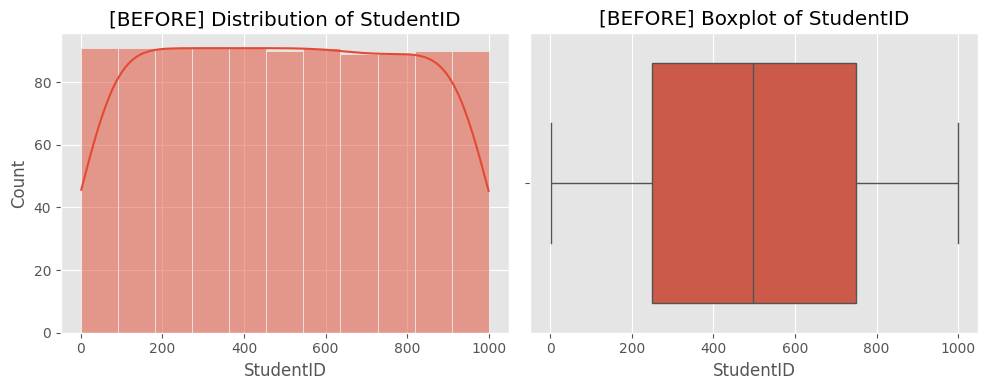

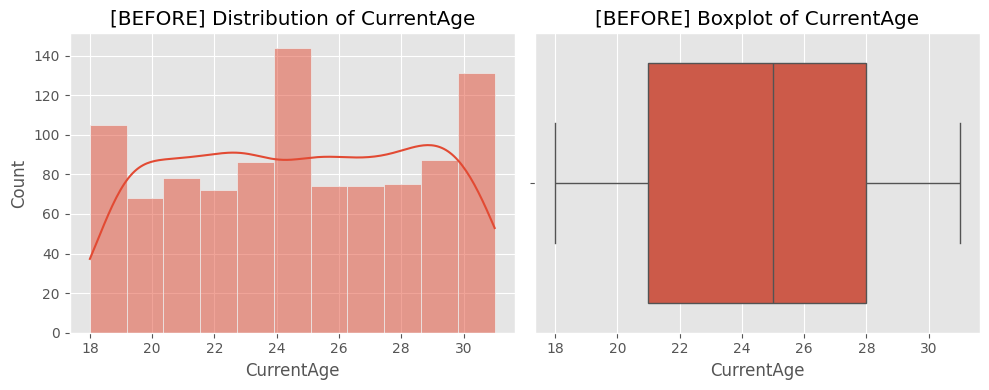

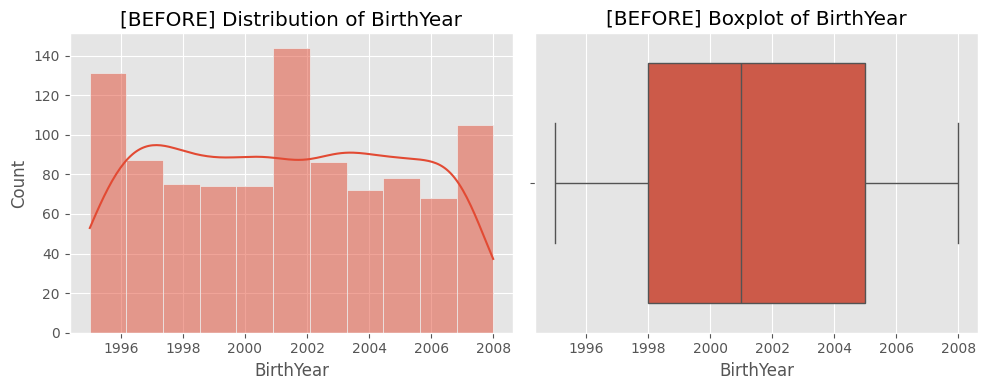

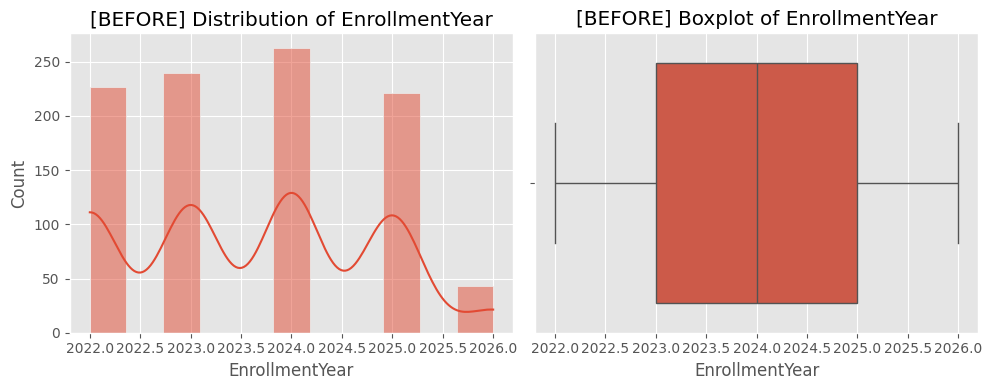

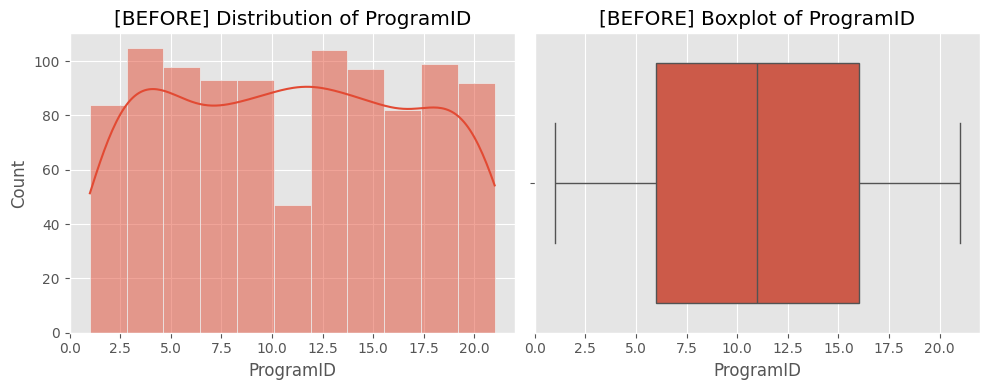

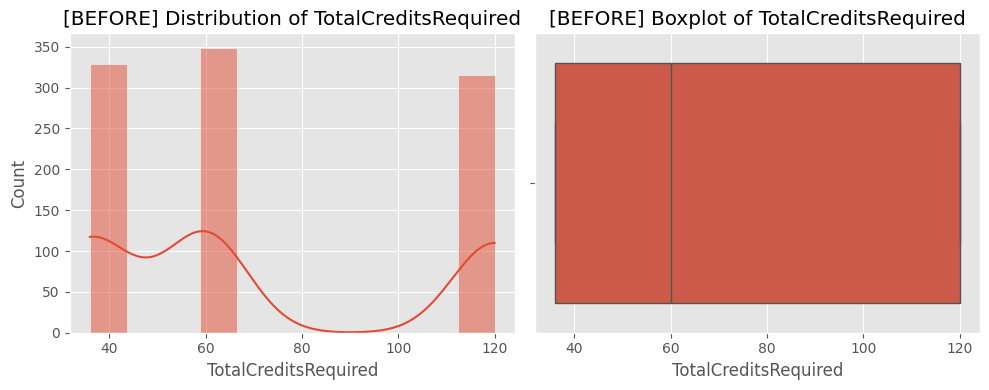

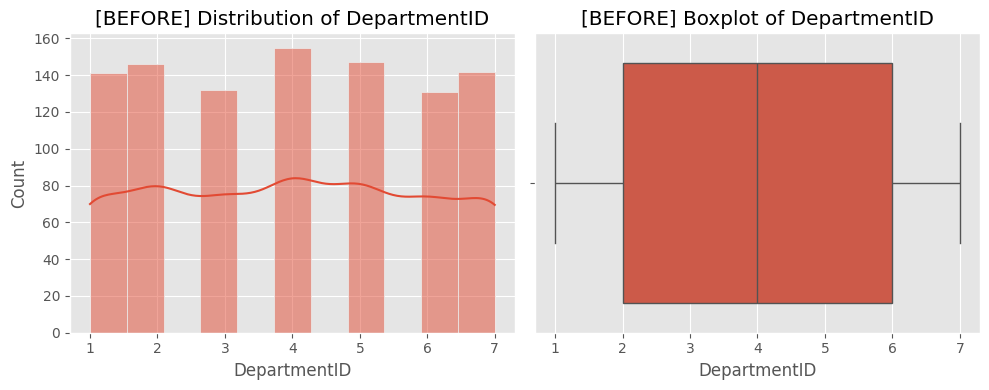

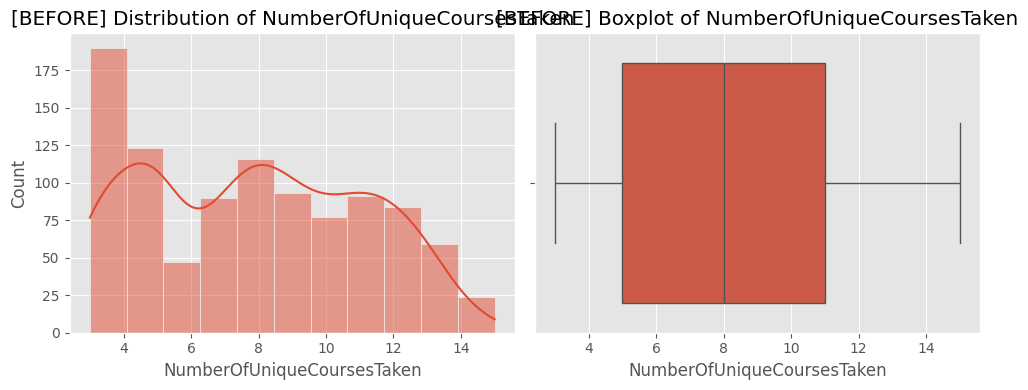

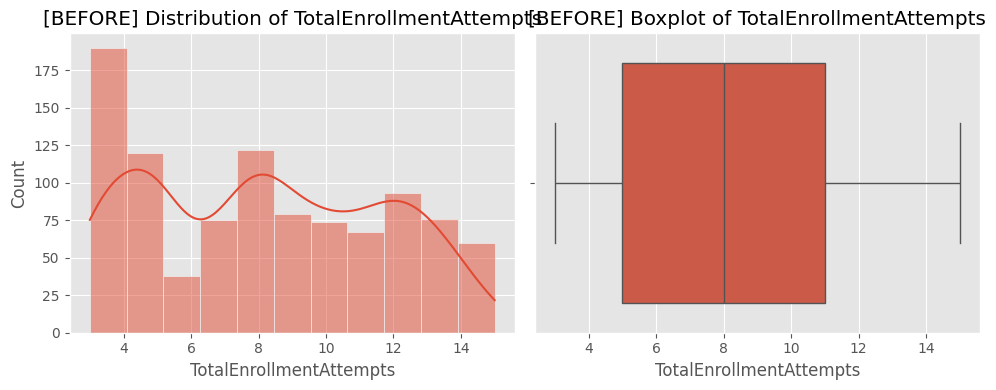

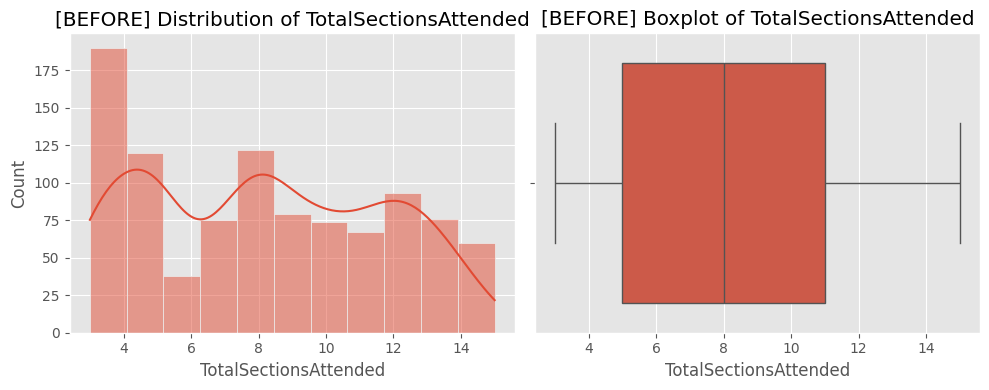

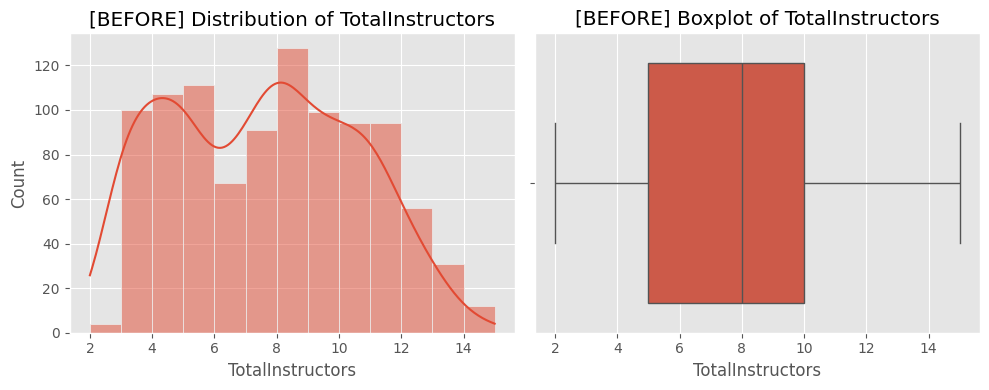

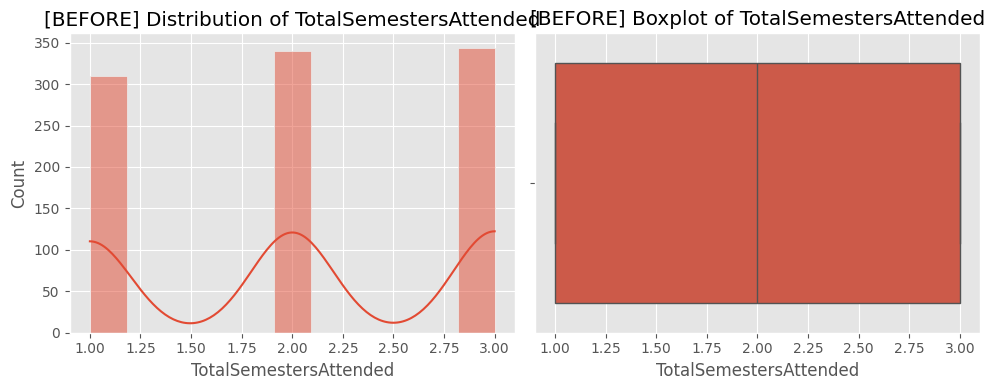

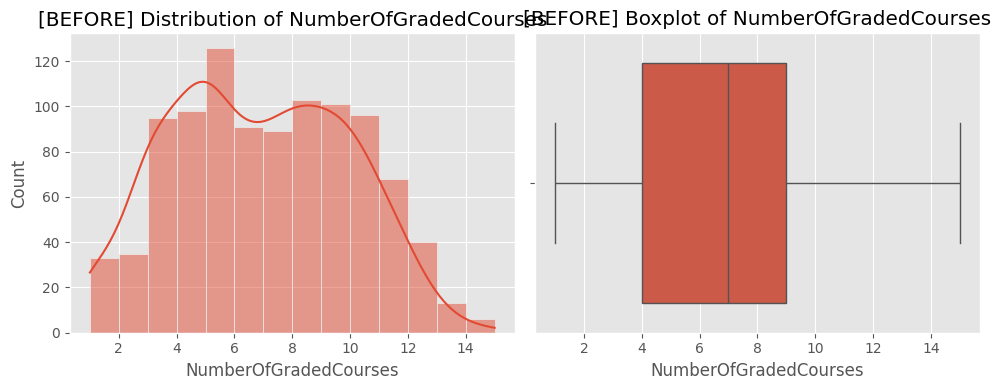

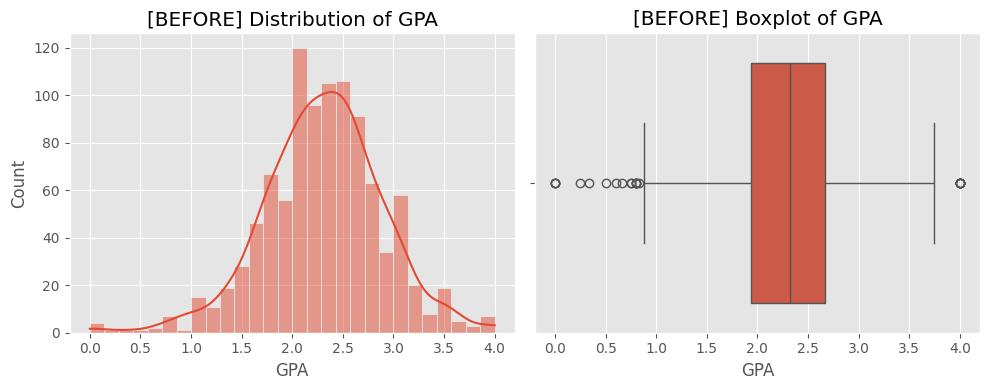

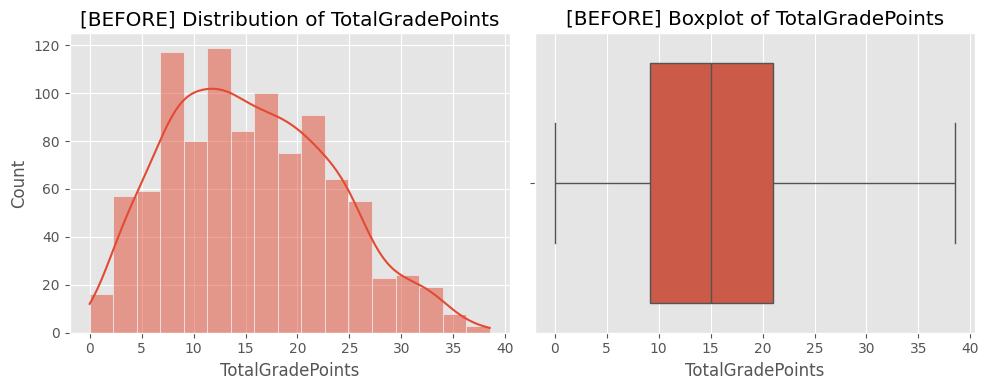

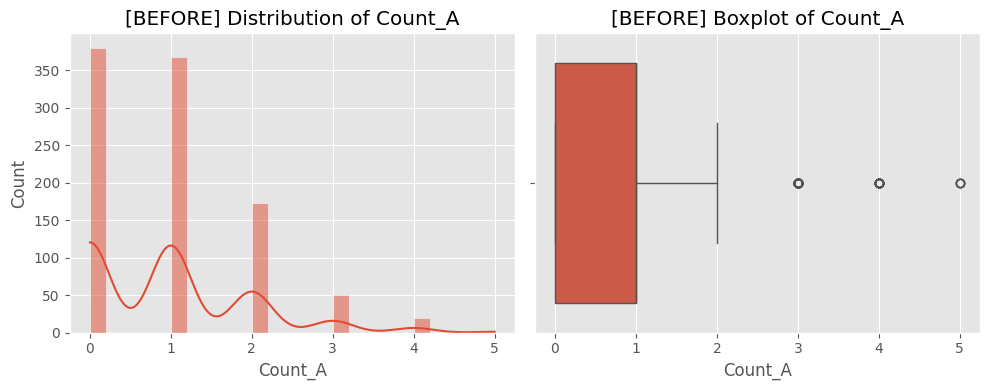

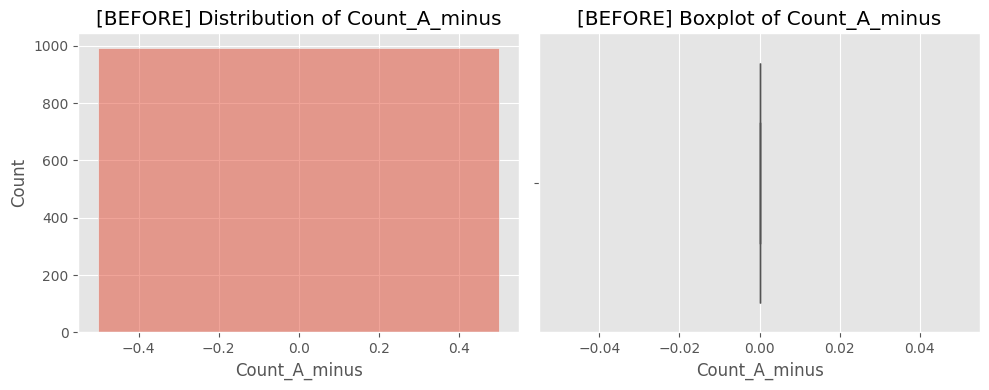

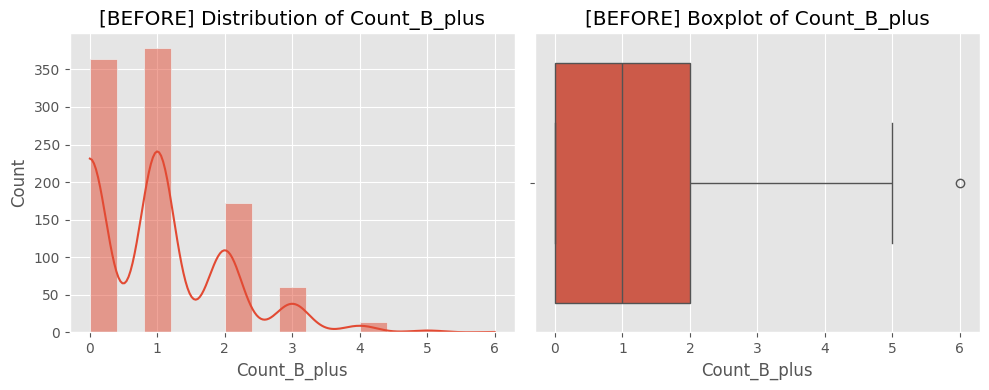

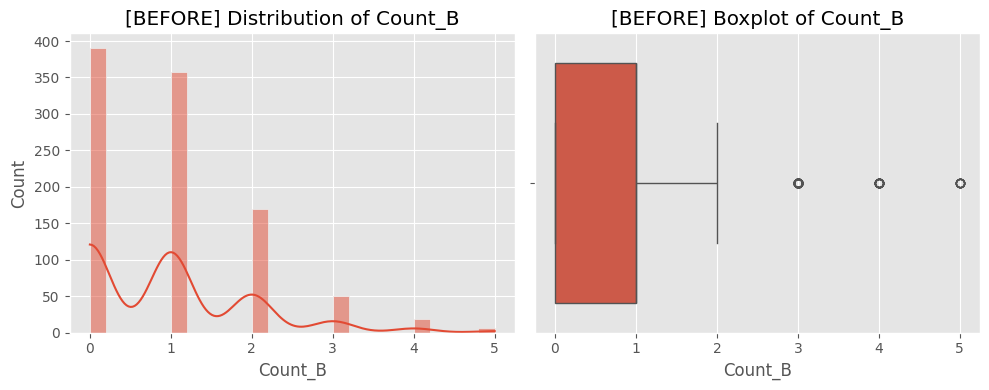

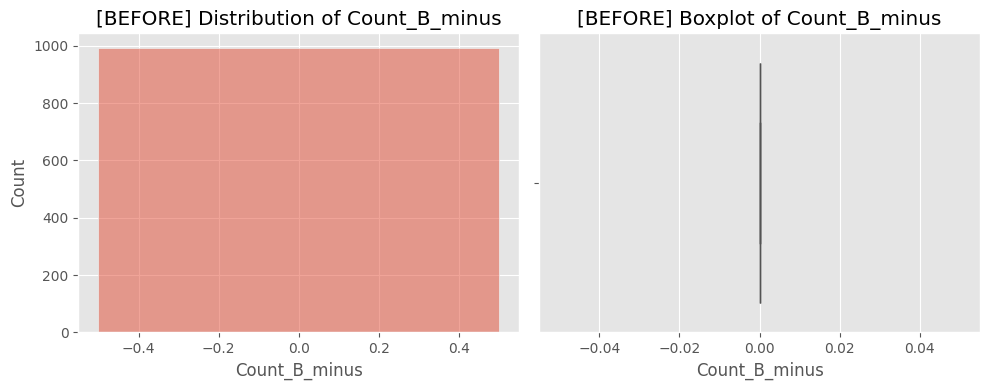

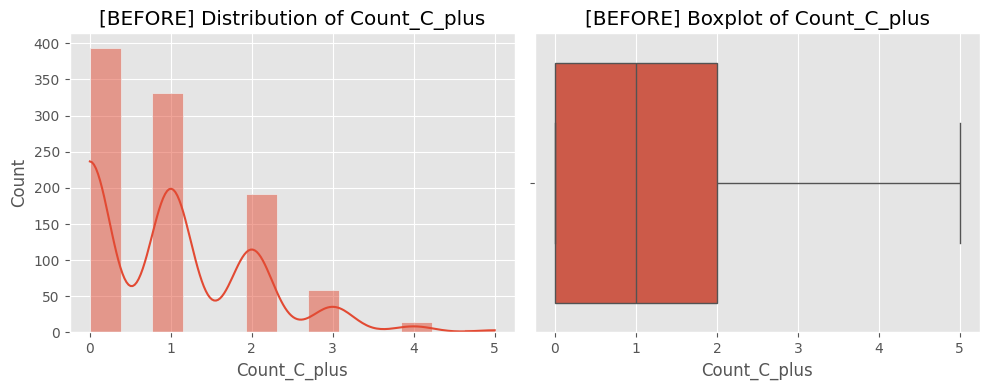

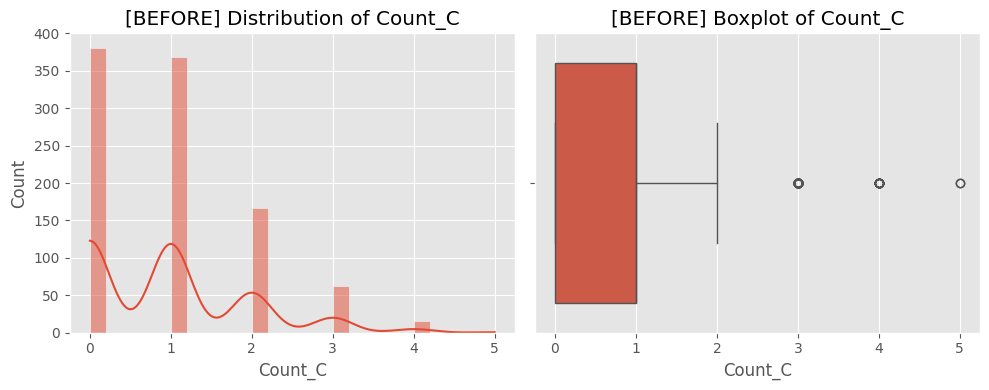

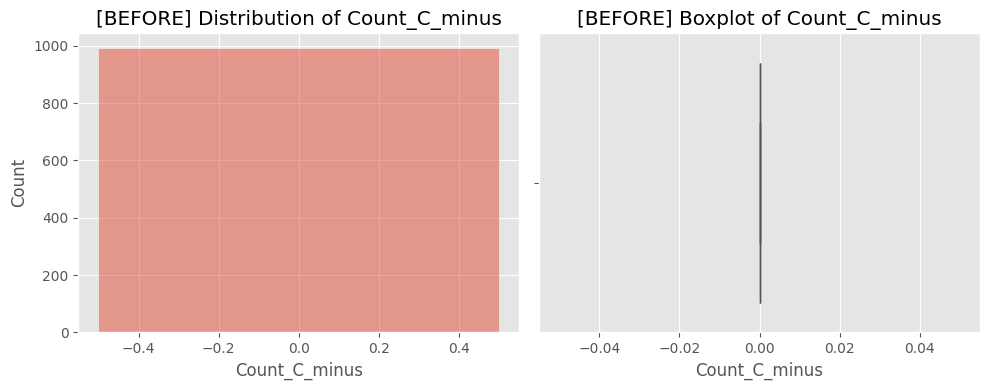

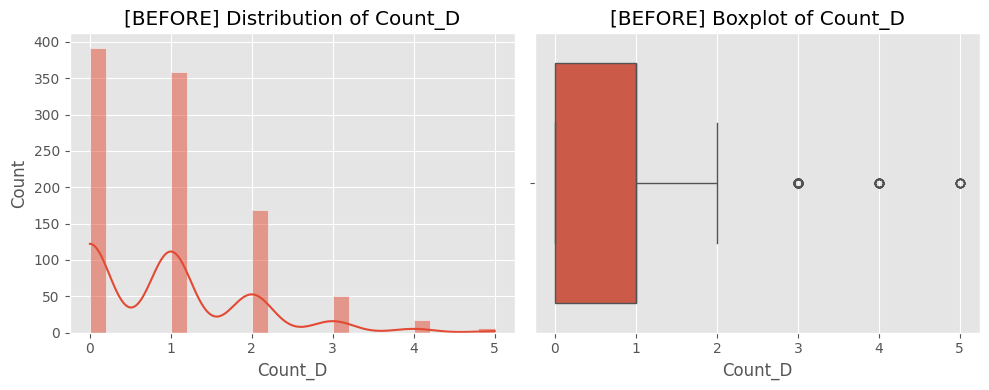

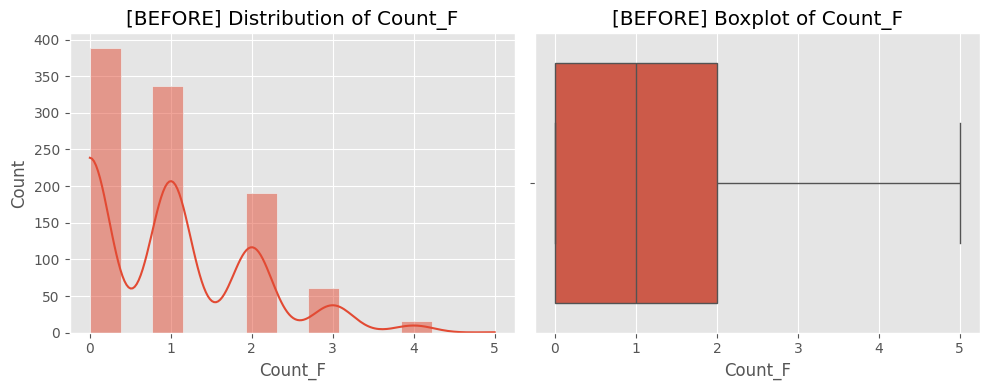

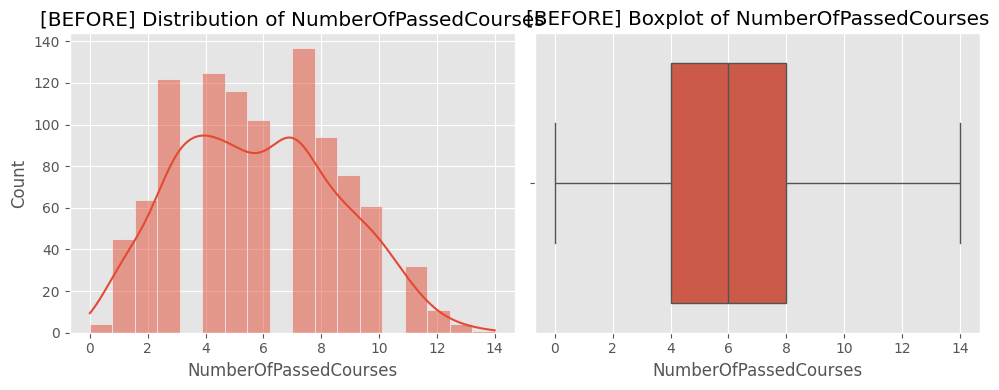

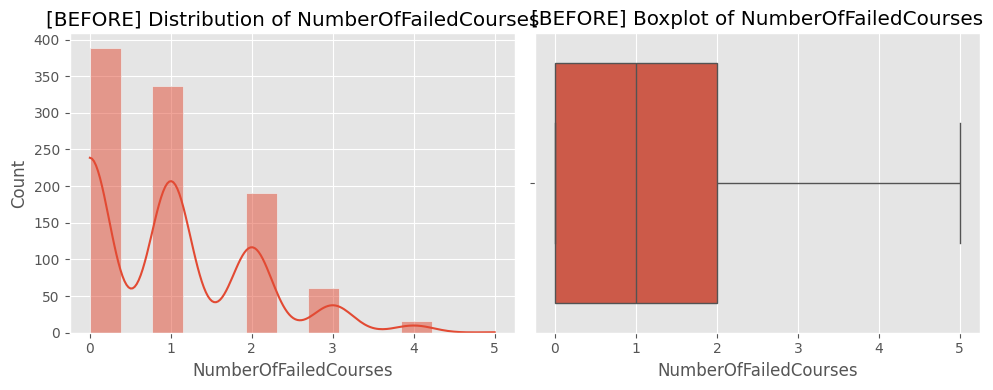

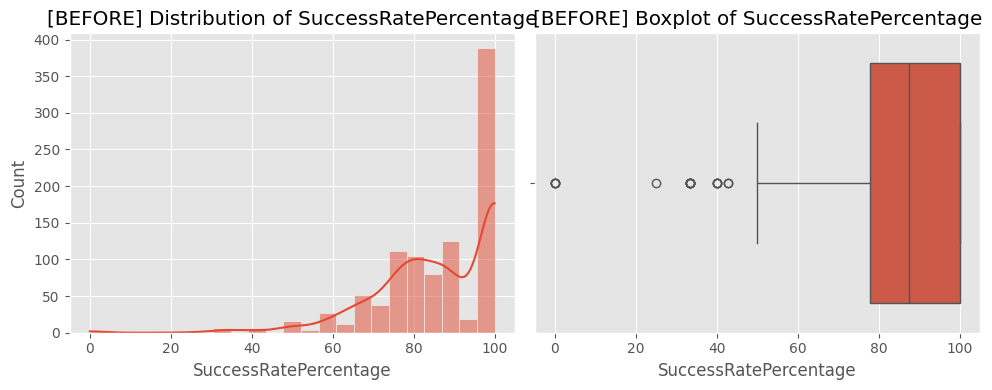

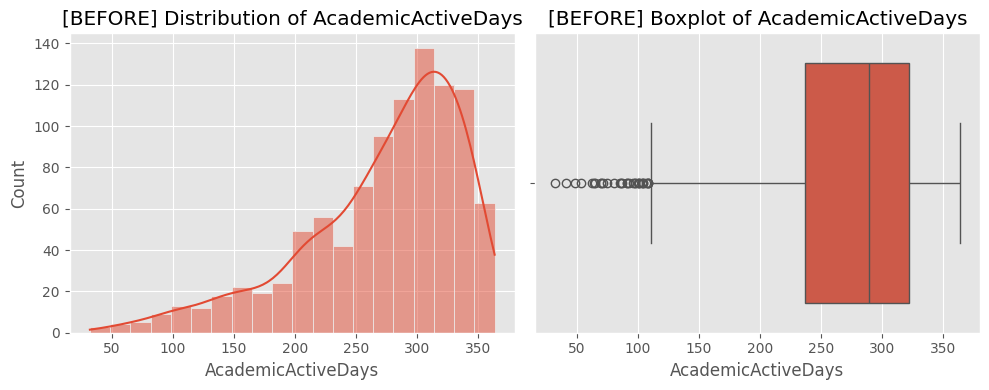

In [34]:
# ==============================
# BEFORE CLEANING - Visualizations
# ==============================

numeric_cols_raw = dfc1.select_dtypes(include=['int64','float64']).columns
numeric_cols_raw = numeric_cols_raw.drop('StudentID')


numeric_cols_raw = dfc1.select_dtypes(include=['int64','float64']).columns

print("=== BEFORE CLEANING: Numeric Distributions ===")
for col in numeric_cols_raw:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(dfc1[col], kde=True, ax=ax[0])
    ax[0].set_title(f"[BEFORE] Distribution of {col}")
    sns.boxplot(x=dfc1[col], ax=ax[1])
    ax[1].set_title(f"[BEFORE] Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [19]:
#  :** فحص الصفوف المكررة

In [35]:
# ==============================
# Duplicate Student IDs
# ==============================
print("Duplicate StudentIDs:")
print(dfc1['StudentID'].duplicated().sum())

Duplicate StudentIDs:
0


In [20]:
# ==============================
# - Duplicate Rows
# ==============================

print("\nDuplicate Rows:")
print(dfc1.duplicated().sum())


Duplicate Rows:
0


In [21]:
### B) جودة البيانات: :** تقرير القيم المفقودة (العدد والنسبة)

In [22]:
# ==============================
# 5- Missing Values
# ==============================

missing = dfc1.isnull().sum()
print(missing[missing > 0])

GPA                   6
TotalGradePoints      6
HighestGradeLetter    6
LowestGradeLetter     6
dtype: int64


In [23]:
dfc1 = dfc1.dropna()

In [24]:
# :** فحص القيم غير المنطقية (مبالغ سالبة، تواريخ مستقبلية...)

In [25]:
#Check for wrong values
checks = [
    ("GPA out of range (0-4)", (dfc1['GPA'] < 0) | (dfc1['GPA'] > 4)),
    ("SuccessRate out of range (0-100)", (dfc1['SuccessRatePercentage'] < 0) | (dfc1['SuccessRatePercentage'] > 100)),
    ("CurrentAge < 16", dfc1['CurrentAge'] < 16),
    ("Enrollment age < 16", (dfc1['EnrollmentYear'] - dfc1['BirthYear']) < 16),
    ("Passed > GradedCourses", dfc1['NumberOfPassedCourses'] > dfc1['NumberOfGradedCourses']),
    ("FailedCourses != Count_F", dfc1['NumberOfFailedCourses'] != dfc1['Count_F'])
]


for name, condition in checks:
    count = condition.sum()
    print(name, "→", count, "rows" if count>0 else "OK")

GPA out of range (0-4) → 0 OK
SuccessRate out of range (0-100) → 0 OK
CurrentAge < 16 → 0 OK
Enrollment age < 16 → 22 rows
Passed > GradedCourses → 0 OK
FailedCourses != Count_F → 0 OK


In [26]:
dfc1[(dfc1['EnrollmentYear'] - dfc1['BirthYear']) < 16]

,StudentID,StudentFullName,FirstName,LastName,StudentEmail,StudentPhone,Gender,DateOfBirth,CurrentAge,BirthYear,UniversityStartDate,EnrollmentYear,CurrentStudentStatus,ProgramID,ProgramName,DegreeLevel,TotalCreditsRequired,DepartmentID,DepartmentName,HeadOfDepartment,NumberOfUniqueCoursesTaken,TotalEnrollmentAttempts,TotalSectionsAttended,TotalInstructors,TotalSemestersAttended,NumberOfGradedCourses,GPA,TotalGradePoints,HighestGradeLetter,LowestGradeLetter,Count_A,Count_A_minus,Count_B_plus,Count_B,Count_B_minus,Count_C_plus,Count_C,Count_C_minus,Count_D,Count_F,NumberOfPassedCourses,NumberOfFailedCourses,SuccessRatePercentage,FirstCourseEnrollmentDate,LastCourseEnrollmentDate,FirstSemesterAttended,LastSemesterAttended,AcademicActiveDays
55,501,Kyle Williams,Kyle,Williams,kyle.williams501@student.university.edu,(333)553-3106x0053,Male,2007-08-22,19,2007,2022-07-24,2022,Active,18,PhD in Engineering,PhD,60,6,Engineering,Melissa Peterson,13,14,14,13,3,11,2.181818,24.0,F,A,1,0,2,3,0,0,1,0,2,2,9,2,81.818182,2025-04-07 19:47:42,2026-02-21 23:22:04,Fall 2023,Spring 2024,320
97,227,Sean Stevenson,Sean,Stevenson,sean.stevenson227@student.university.edu,886.738.4066,Male,2007-09-24,19,2007,2022-05-22,2022,Active,2,Master in Computer Science,Master,36,1,Computer Science,Allison Hill,12,13,13,9,3,9,2.277777,20.5,F,A,1,0,0,3,0,1,2,0,1,1,8,1,88.888889,2025-05-21 14:13:47,2026-01-31 21:03:20,Fall 2023,Spring 2024,255
133,920,James Jordan,James,Jordan,james.jordan920@student.university.edu,248-986-0849,Male,2008-01-12,18,2008,2023-01-10,2023,Active,5,Master in Mathematics,Master,36,2,Mathematics,Megan Mcclain,13,13,13,11,3,9,1.388888,12.5,F,B+,0,0,1,0,0,2,1,0,2,3,6,3,66.666667,2025-04-04 16:25:04,2026-01-18 13:47:52,Fall 2023,Spring 2024,289
140,392,Teresa Rush,Teresa,Rush,teresa.rush392@student.university.edu,(552)589-3891x190,Female,2007-09-17,19,2007,2022-11-10,2022,Active,1,Bachelor in Computer Science,Bachelor,120,1,Computer Science,Allison Hill,12,12,12,12,3,11,1.545454,17.0,F,A,1,0,1,1,0,1,0,0,4,3,8,3,72.727273,2025-03-13 13:50:29,2026-03-04 12:26:04,Fall 2023,Spring 2024,356
190,968,Christina Watkins,Christina,Watkins,christina.watkins968@student.university.edu,+1-937-732-6530x6011,Female,2008-01-24,18,2008,2022-07-22,2022,Graduated,16,Bachelor in Engineering,Bachelor,120,6,Engineering,Melissa Peterson,12,12,12,11,3,10,1.750000,17.5,F,A,1,0,1,2,0,0,1,0,2,3,7,3,70.000000,2025-03-13 05:56:26,2026-01-31 03:02:25,Fall 2023,Spring 2024,324
200,616,Erica Simon,Erica,Simon,erica.simon616@student.university.edu,314.341.5833,Female,2007-10-22,19,2007,2022-06-01,2022,Active,14,Master in Business Administration,Master,36,5,Business Administration,Kevin Pacheco,11,12,12,10,3,10,2.950000,29.5,C+,A,3,0,0,1,0,5,1,0,0,0,10,0,100.000000,2025-05-13 06:57:26,2026-03-01 12:54:59,Fall 2023,Spring 2024,292
274,787,Anna Dawson,Anna,Dawson,anna.dawson787@student.university.edu,+1-364-725-8562x6149,Female,2008-03-02,18,2008,2023-12-11,2023,Graduated,1,Bachelor in Computer Science,Bachelor,120,1,Computer Science,Allison Hill,11,11,11,10,3,7,2.500000,17.5,D,A,2,0,0,1,0,1,1,0,2,0,7,0,100.000000,2025-03-07 10:58:49,2025-12-17 18:34:42,Fall 2023,Spring 2024,285
304,367,Zachary Vargas,Zachary,Vargas,zachary.vargas367@student.university.edu,240.863.3569x392,Male,2007-12-01,19,2007,2022-05-02,2022,Active,19,Bachelor in Psychology,Bachelor,120,7,Psychology,Gabrielle Davis,9,10,10,8,2,8,1.875000,15.0,F,C,0,0,0,0,0,4,2,0,1,1,7,1,87.500000,2025-06-21 12:07:59,2026-03-02 11:30:16,Fall 2024,Spring 2024,254
317,534,Christopher Peters,Christopher,Peters,christopher.peters534@student.university.edu,610-729-3218x40118,Male,2007-09-26,19,2007,2022-11-10,2022,Active,18,PhD in Engineering,PhD,60,6,Engineering,Melissa Peterson,10,10,10,9,2,7,1.285714,9.0,F,A,1,0,0,1,0,0,1,0,0,4,3,4,42.857143,2025-03-08 19:27:18,2025-11-18 06:56:19,Fall 2023,Fall 2024,255
404,404,Victoria Gray,Victoria,Gray,victoria.gray404@student.university.edu,(659)717-1357x8529,Female,2007-10-11,19,2007,2022-12

In [ ]:
# Some students appear to have enrolled before age 16.
# This may represent early admission cases or potential data entry issues.
# These records will be kept but flagged for review.

In [27]:
dfc2 = dfc1.copy()




In [28]:
# Create a clean copy of the dataset excluding personal identifier columns for EDA
dfc3 = dfc2.copy()
Sensitive_Columns = ["StudentID", "StudentFullName", "FirstName", "LastName", "StudentEmail", "StudentPhone"]
dfc3 = dfc3.drop(columns=Sensitive_Columns)
print("Shape before removing Sensitive Columns:", dfc3.shape)

Shape before removing Sensitive Columns: (994, 42)


In [29]:
# :** فحص أنواع البيانات وتحديد المشاكل

In [30]:
# Convert "DepartmentID" and "ProgramID" columns to categorical type
dfc2["DepartmentID"] = dfc2["DepartmentID"].astype("category")
dfc2["ProgramID"] = dfc2["ProgramID"].astype("category")

In [31]:
# Remove columns with a single unique value (constant columns)

print("Shape before removing constant columns:", dfc3.shape)
dfc4 = dfc3.copy()
constant_columns = [col for col in dfc4.columns if dfc4[col].nunique() == 1]
dfc4 = dfc4.drop(columns=constant_columns)
print('#'*100)
# Print shape after removing constant columns
print("Shape after removing constant columns:", dfc4.shape)

Shape before removing constant columns: (994, 42)
####################################################################################################
Shape after removing constant columns: (994, 39)


In [32]:
# ==============================
# 6- Separate Column Types
# ==============================

numeric_cols = dfc4.select_dtypes(include=['int64','float64']).columns
categorical_cols = dfc4.select_dtypes(include=['object']).columns

print("\nNumeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numeric Columns:
Index(['CurrentAge', 'BirthYear', 'EnrollmentYear', 'ProgramID',
       'TotalCreditsRequired', 'DepartmentID', 'NumberOfUniqueCoursesTaken',
       'TotalEnrollmentAttempts', 'TotalSectionsAttended', 'TotalInstructors',
       'TotalSemestersAttended', 'NumberOfGradedCourses', 'GPA',
       'TotalGradePoints', 'Count_A', 'Count_B_plus', 'Count_B',
       'Count_C_plus', 'Count_C', 'Count_D', 'Count_F',
       'NumberOfPassedCourses', 'NumberOfFailedCourses',
       'SuccessRatePercentage', 'AcademicActiveDays'],
      dtype='object')

Categorical Columns:
Index(['Gender', 'CurrentStudentStatus', 'ProgramName', 'DegreeLevel',
       'DepartmentName', 'HeadOfDepartment', 'HighestGradeLetter',
       'LowestGradeLetter', 'FirstSemesterAttended', 'LastSemesterAttended'],
      dtype='object')


In [ ]:
# :** نظافة التصنيفات (أخطاء إملائية، حالة الأحرف، مسافات زائدة)

for col in categorical_cols:
    has_spaces = dfc4[col].str.strip().ne(dfc4[col]).sum()

    print(f"{col:<30} |  spaces: {has_spaces}")

Gender                         |  spaces: 0
CurrentStudentStatus           |  spaces: 0
ProgramName                    |  spaces: 0
DegreeLevel                    |  spaces: 0
DepartmentName                 |  spaces: 0
HeadOfDepartment               |  spaces: 0
HighestGradeLetter             |  spaces: 0
LowestGradeLetter              |  spaces: 0
FirstSemesterAttended          |  spaces: 0
LastSemesterAttended           |  spaces: 0


In [ ]:
# :** توزيعات الأعمدة الرقمية (Histograms + تحديد الانحراف)

In [ ]:
dfc4.select_dtypes(include='number').skew().sort_values()

,0
SuccessRatePercentage,-1.461489
AcademicActiveDays,-1.102853
GPA,-0.265530
TotalSemestersAttended,-0.062527
CurrentAge,-0.018539
DepartmentID,0.008251
BirthYear,0.018539
ProgramID,0.021060
NumberOfGradedCourses,0.085574
NumberOfUniqueCoursesTaken,0.106436


In [ ]:
#:** القيم المتطرفة (Boxplots + إجراء مقترح)


Univariate Analysis: Numeric Columns


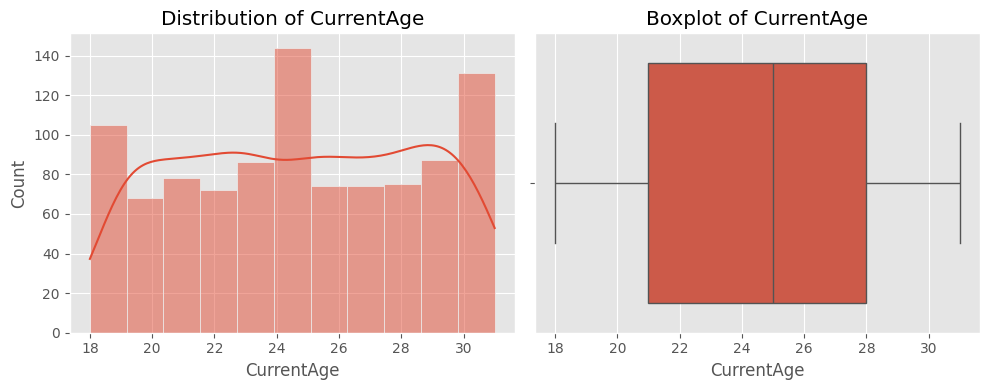

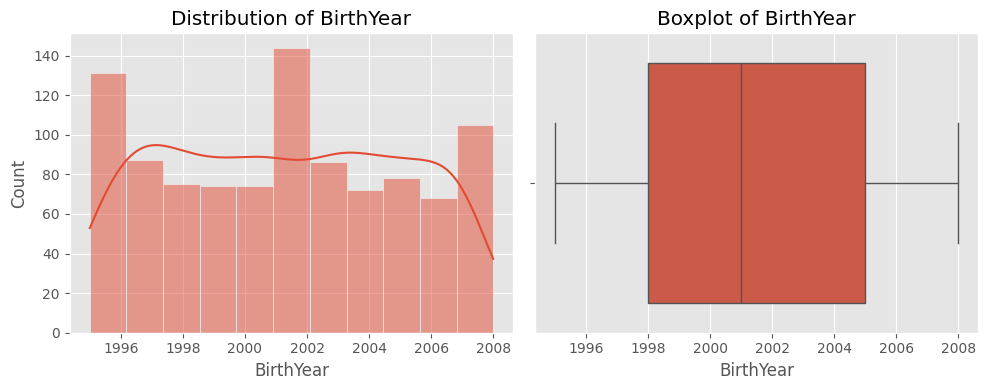

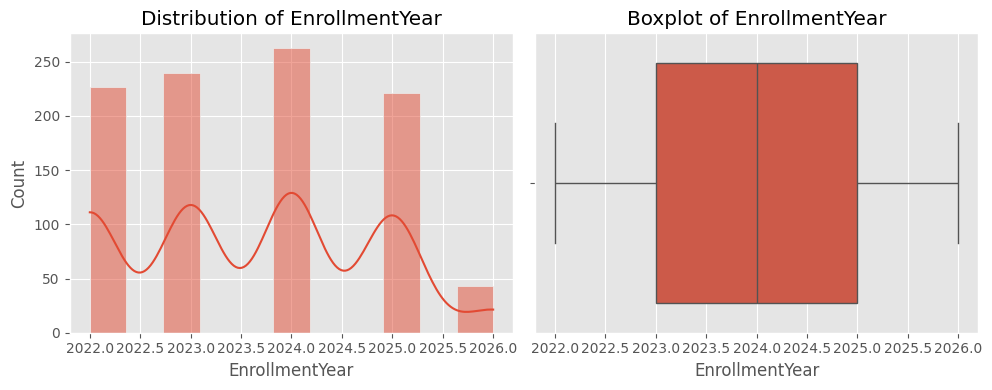

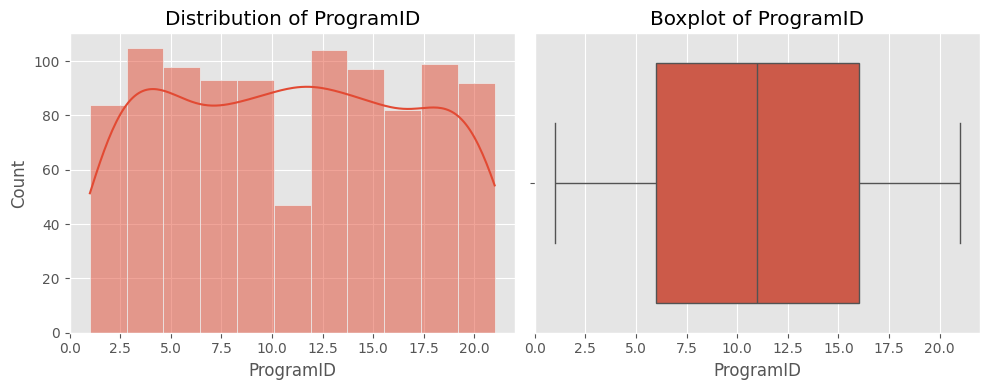

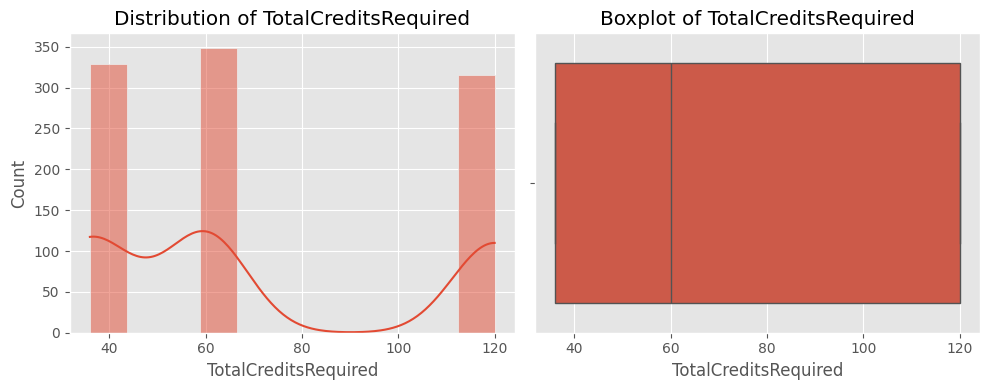

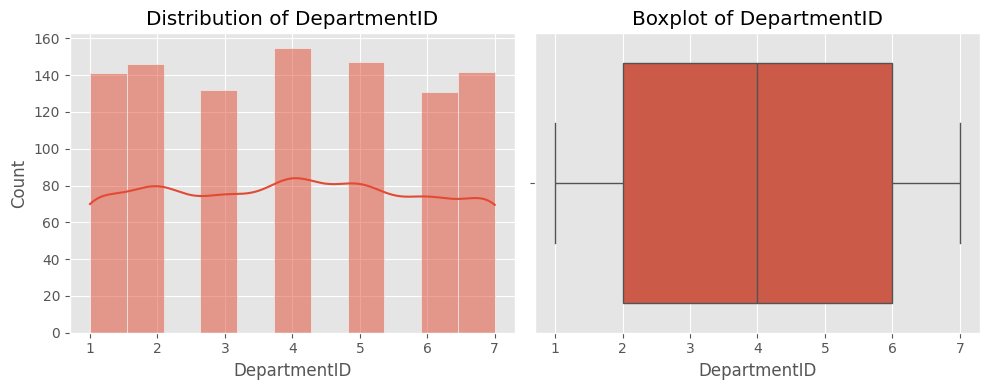

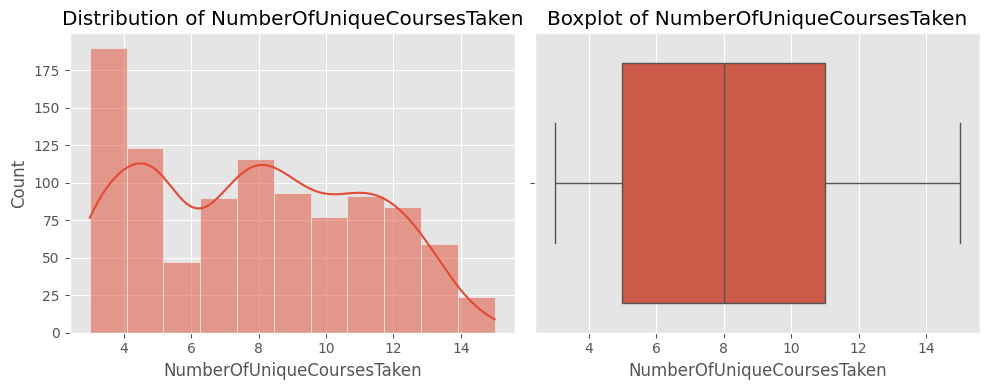

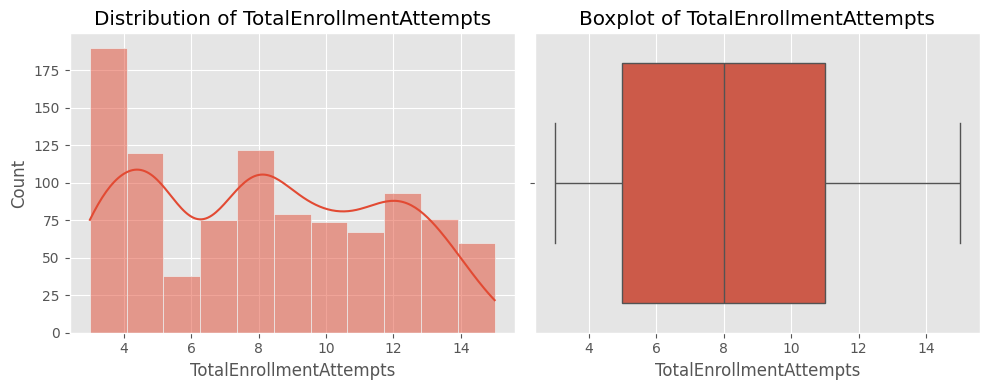

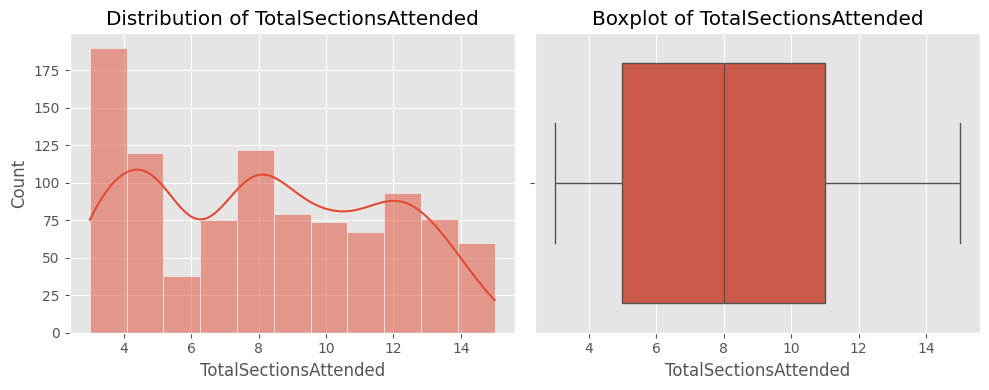

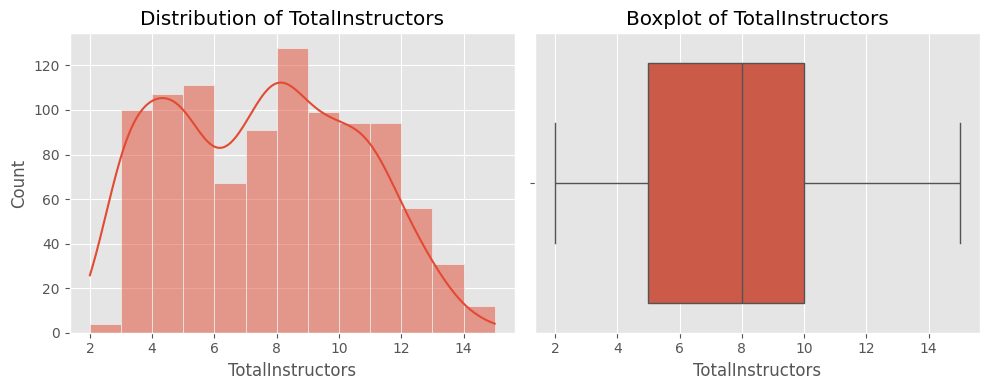

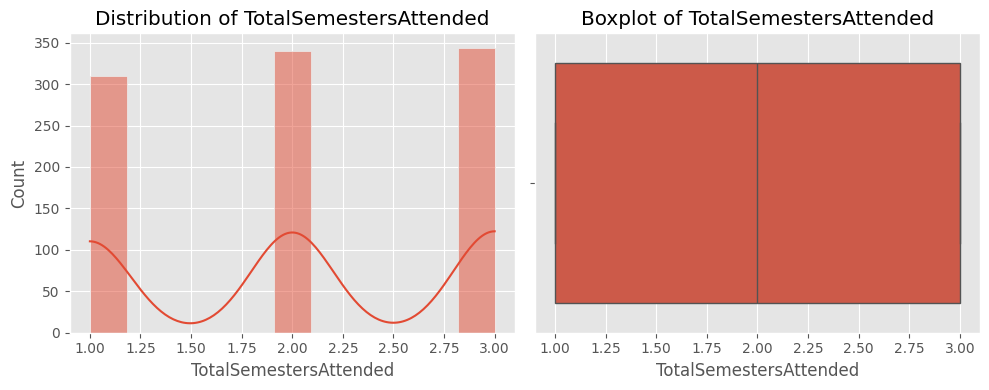

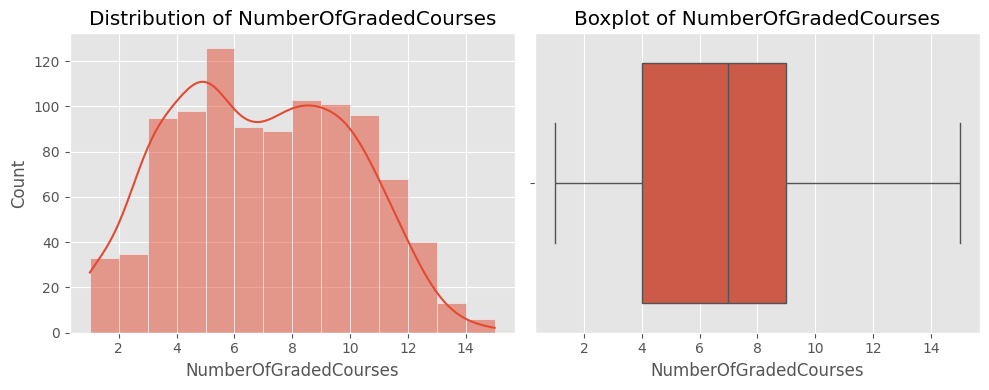

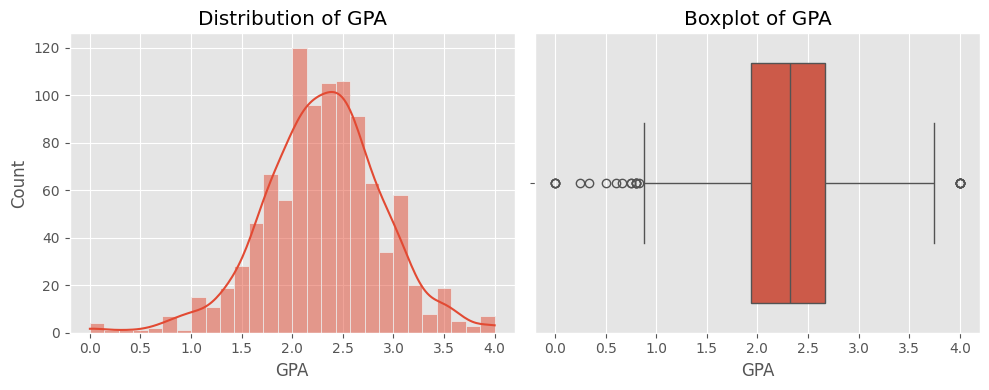

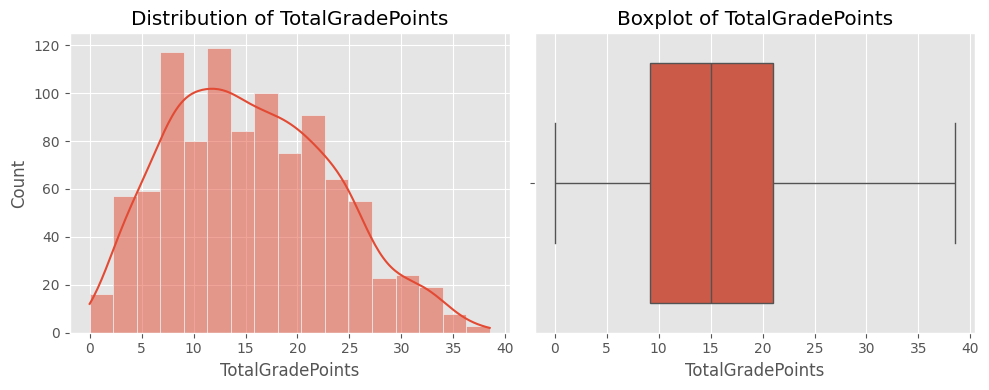

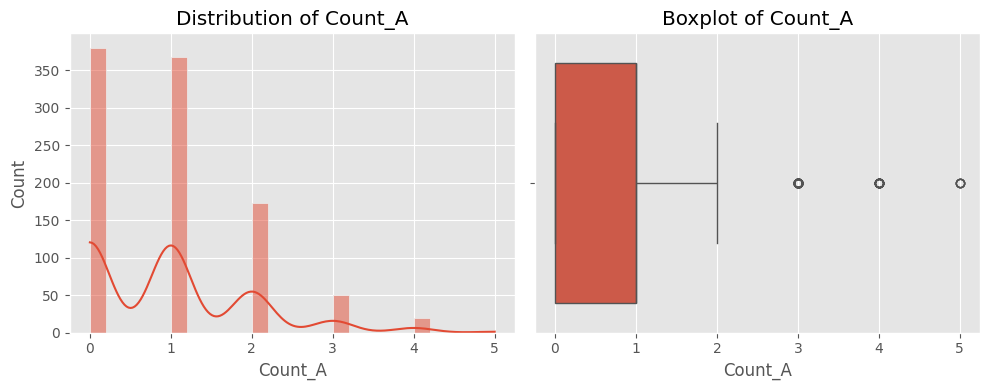

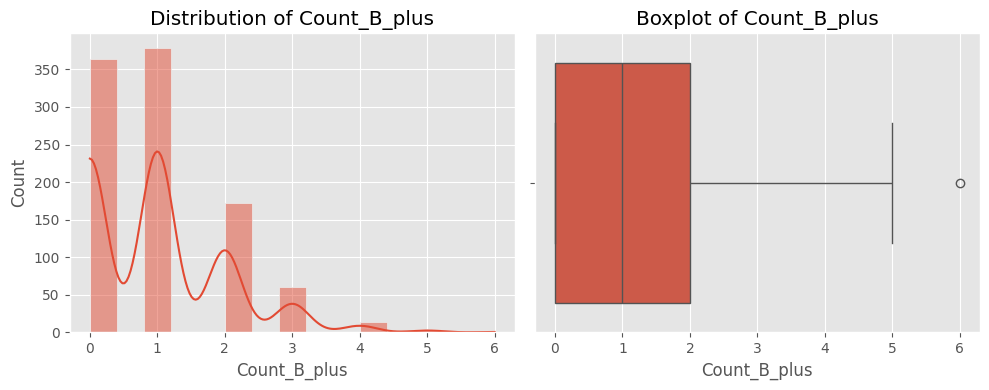

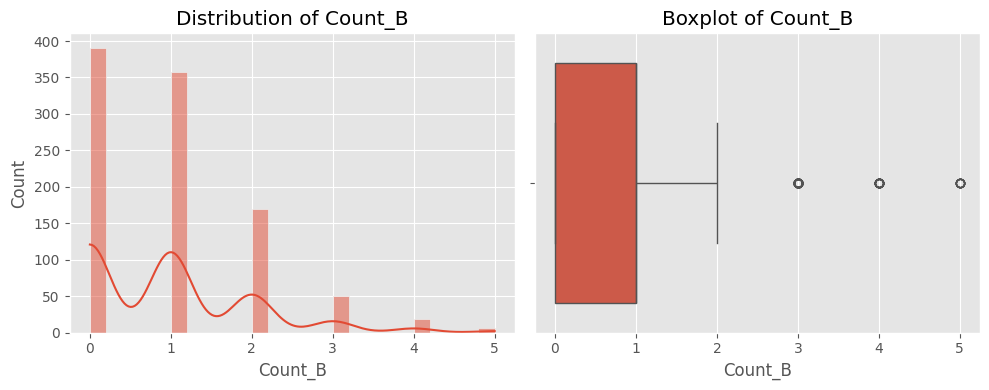

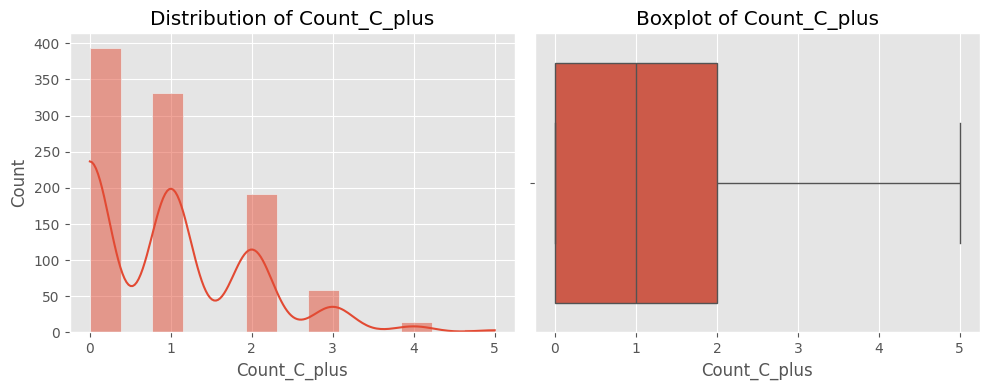

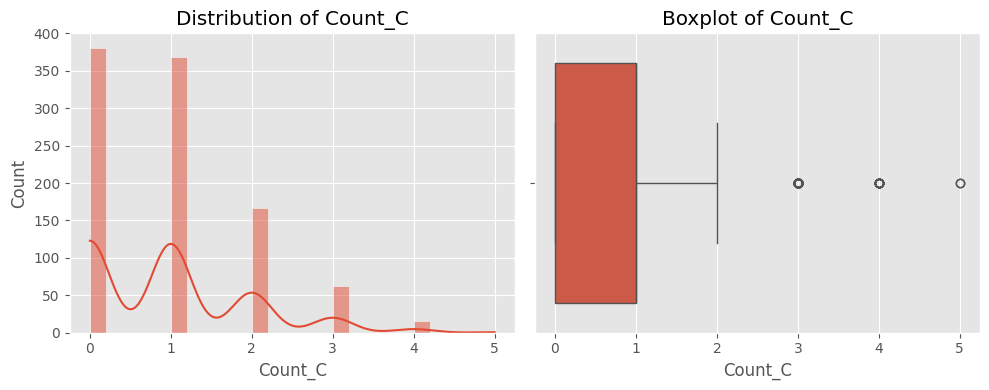

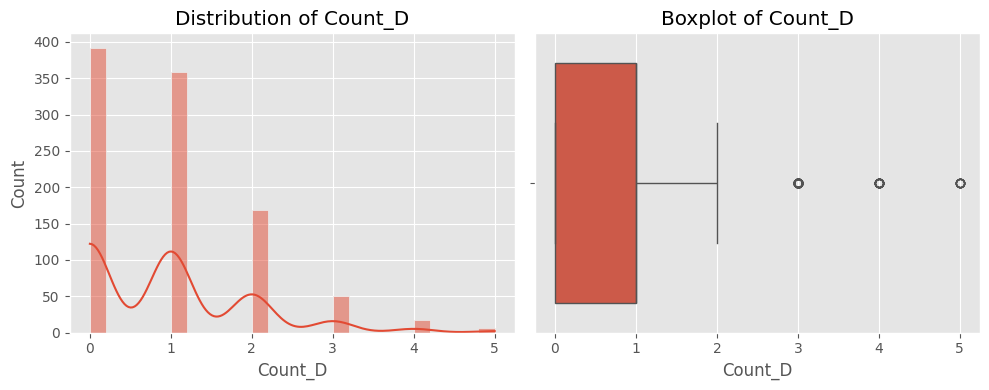

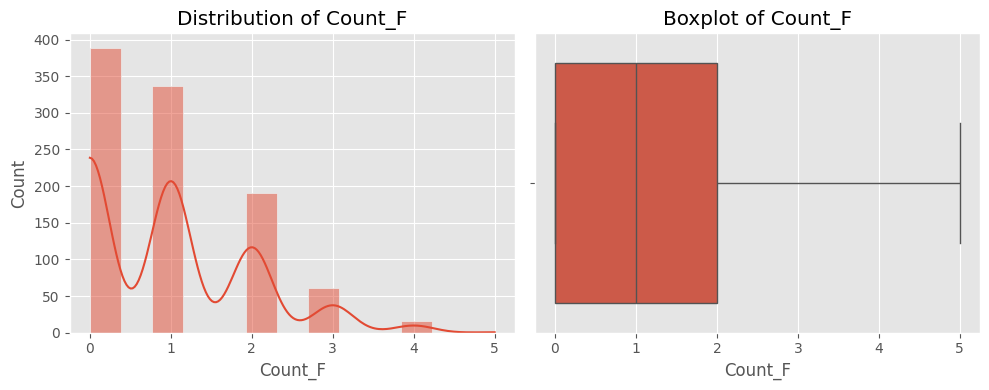

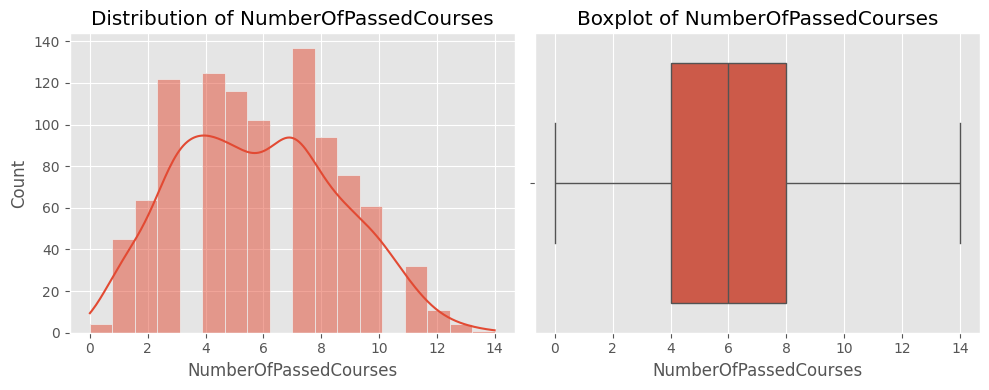

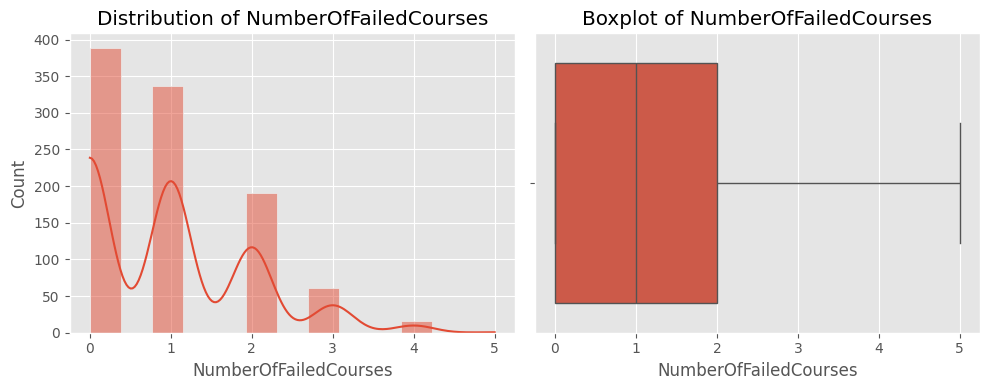

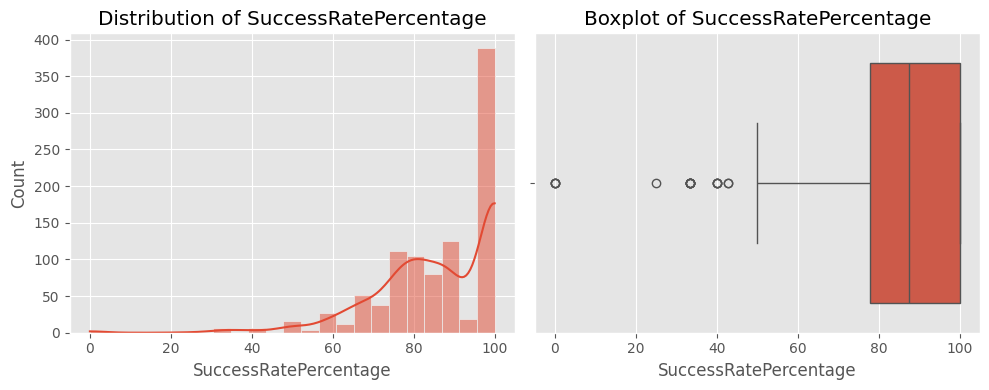

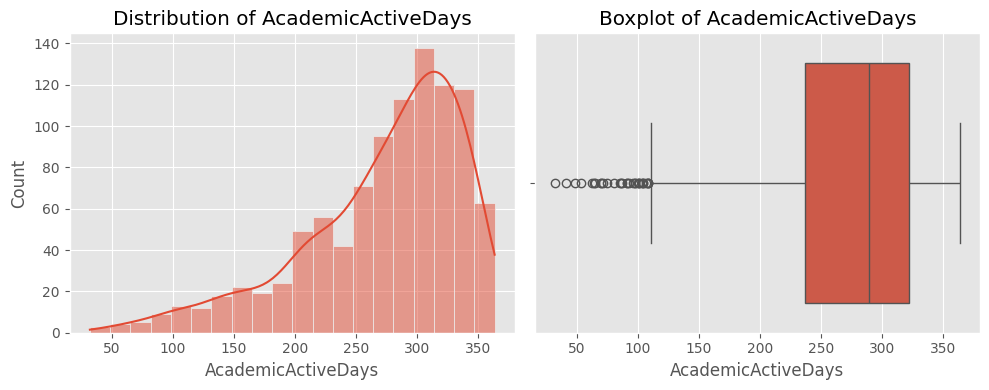

In [ ]:
# ==============================
# 7- Univariate Analysis
# ==============================

print("\nUnivariate Analysis: Numeric Columns")

for col in numeric_cols:

    fig, ax = plt.subplots(1,2, figsize=(10,4))

    sns.histplot(dfc4[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=dfc4[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()



Univariate Analysis: Categorical Columns


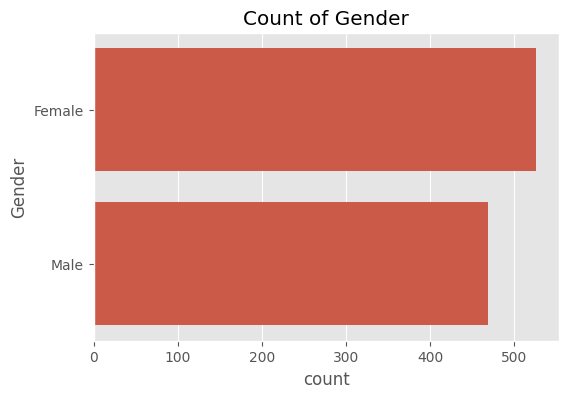

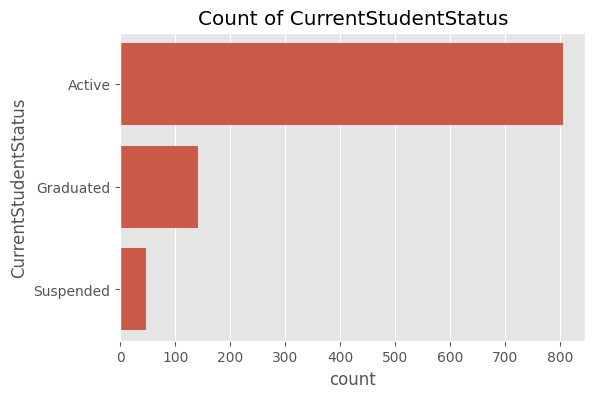

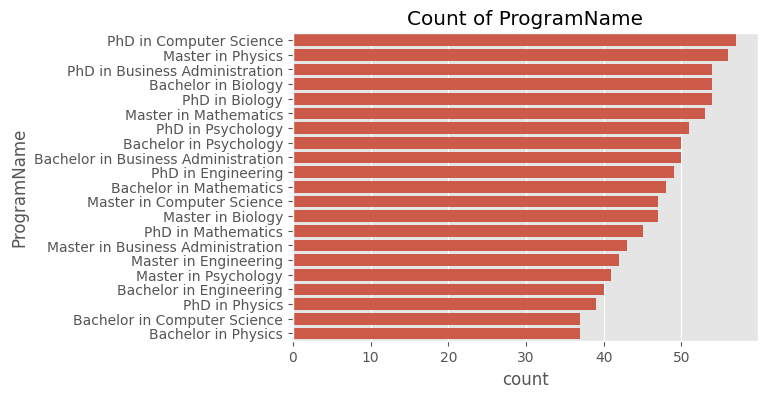

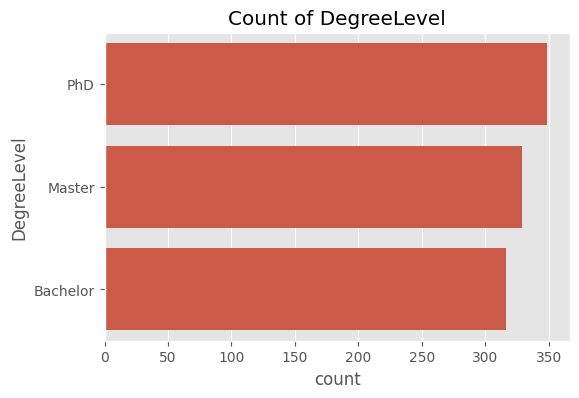

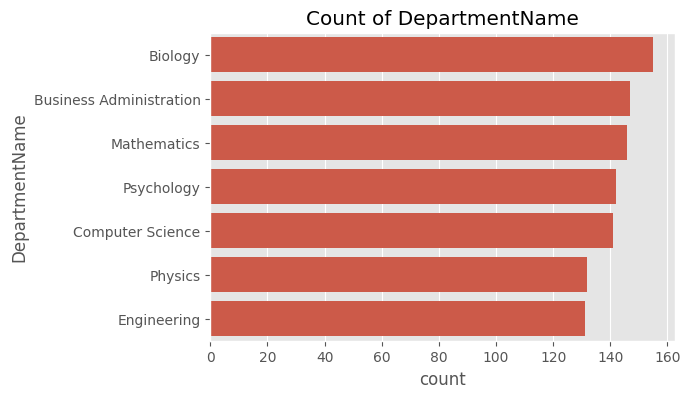

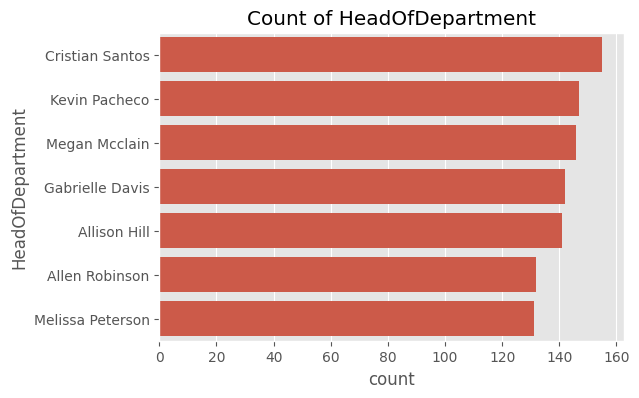

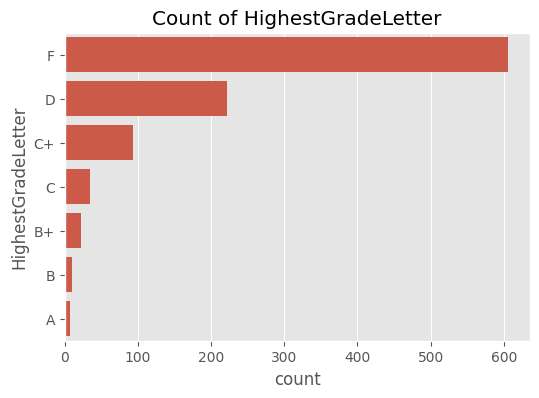

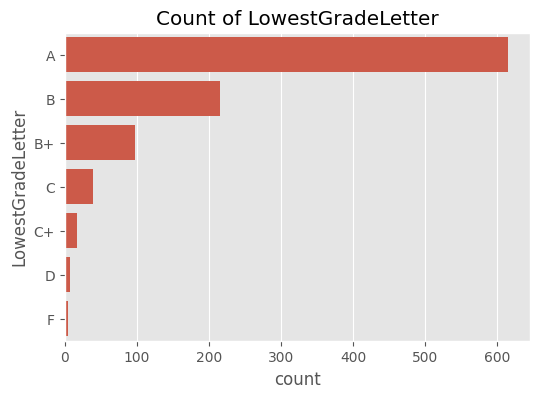

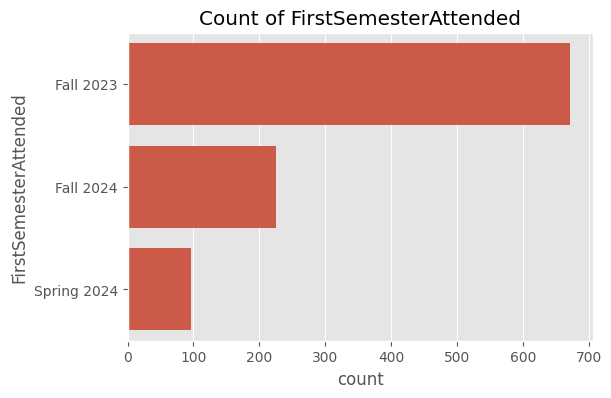

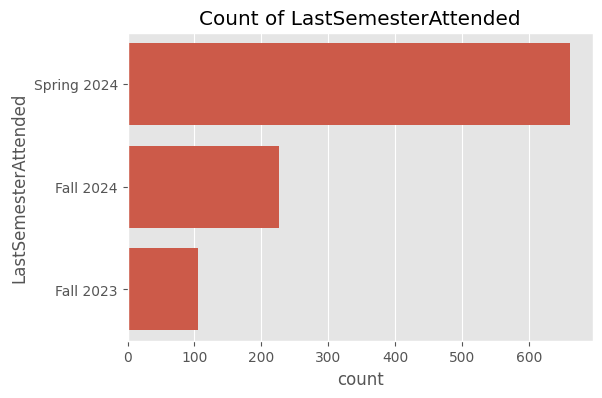

In [ ]:
# ==============================
# 9- Categorical Analysis
# ==============================

print("\nUnivariate Analysis: Categorical Columns")

for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(y=dfc4[col], order=dfc4[col].value_counts().index)

    plt.title(f"Count of {col}")
    plt.show()

In [ ]:
# ==============================
# 10- Bivariate Analysis
# ==============================

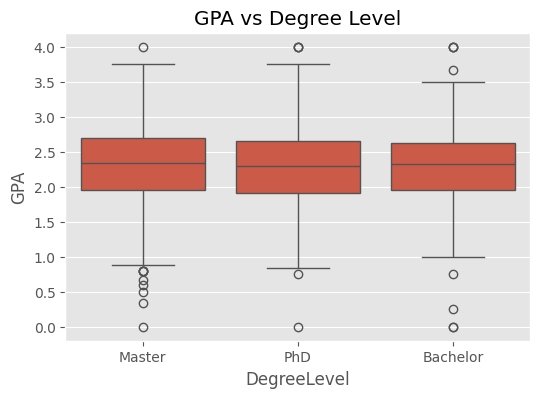

In [ ]:
# GPA vs Degree Level
plt.figure(figsize=(6,4))
sns.boxplot(x='DegreeLevel', y='GPA', data=dfc4)
plt.title("GPA vs Degree Level")
plt.show()


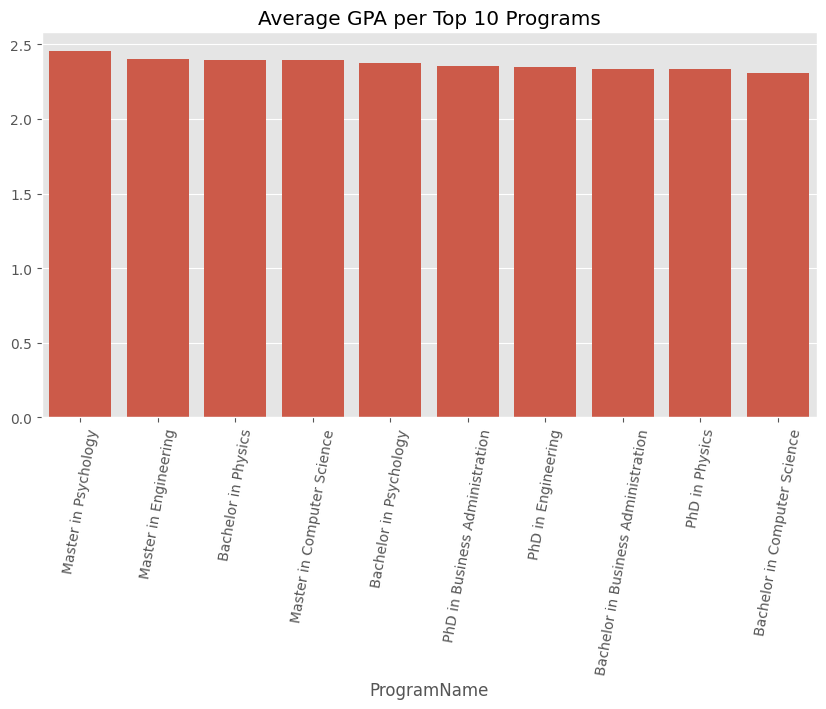

In [ ]:
avg_gpa = dfc4.groupby('ProgramName')['GPA'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_gpa.index, y=avg_gpa.values)
plt.xticks(rotation=80)
plt.title("Average GPA per Top 10 Programs")
plt.show()

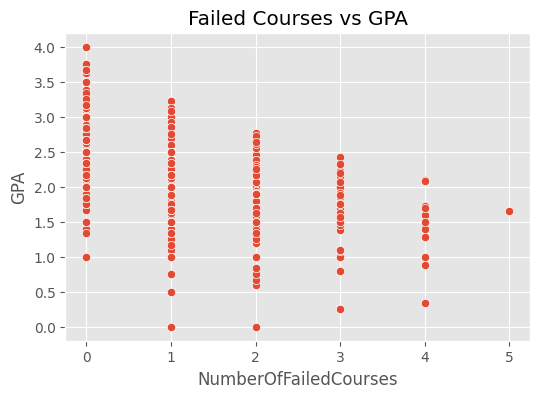

In [ ]:
# GPA vs Failed Courses
plt.figure(figsize=(6,4))
sns.scatterplot(x='NumberOfFailedCourses', y='GPA', data=dfc4)
plt.title("Failed Courses vs GPA")
plt.show()


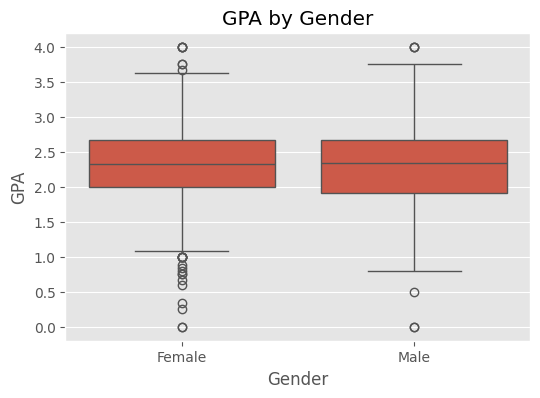

In [ ]:
# GPA vs Gender
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='GPA', data=dfc4)
plt.title("GPA by Gender")
plt.show()

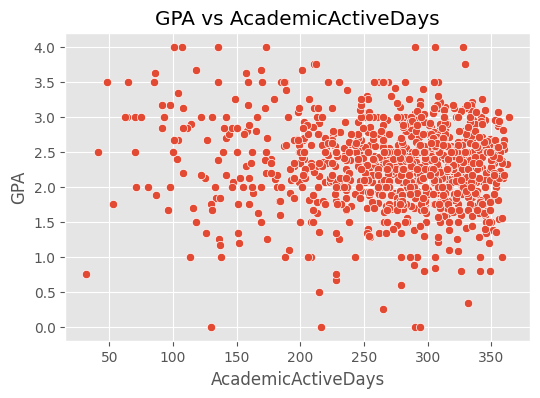

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='AcademicActiveDays', y='GPA', data=dfc4)

plt.title("GPA vs AcademicActiveDays")

plt.show()

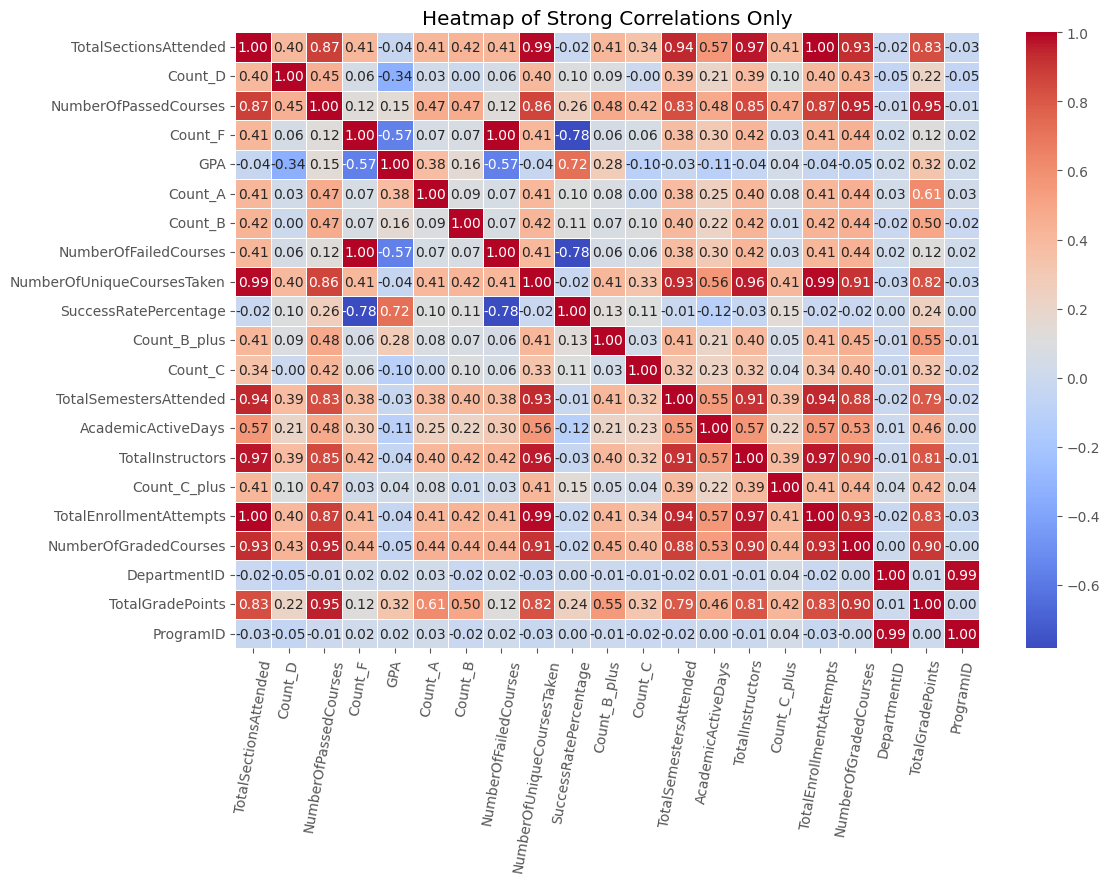

In [ ]:
# ==============================
# Heatmap for Strong Correlations Only
# ==============================

# 2- Correlation matrix
corr_matrix = dfc4[numeric_cols].corr()

# 3- Set threshold
threshold = 0.4

# 4- Get strong correlation pairs
corr_pairs = corr_matrix.unstack()

strong_pairs = corr_pairs[
    (abs(corr_pairs) > threshold) &
    (abs(corr_pairs) < 1)
]

# 5- Get unique columns involved in strong correlations
cols = list(set([i[0] for i in strong_pairs.index] +
                [i[1] for i in strong_pairs.index]))

# 6- Heatmap only for these columns
plt.figure(figsize=(12,8))

sns.heatmap(
    dfc4[cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap of Strong Correlations Only")
plt.xticks(rotation=80)
plt.yticks(rotation=0)

plt.show()

In [36]:
# ============================================================
# E) النتيجة النهائية - Final EDA Report
# ============================================================

print("=" * 60)
print("         📊 FINAL EDA REPORT")
print("=" * 60)

print("""
🔍 أهم 5 Insights:
------------------
1. متوسط الـ GPA = 2.30 — أغلب الطلاب في المستوى المتوسط
2. نسبة النجاح العامة = 85.8% — معظم الطلاب بينجحوا
3. مفيش فرق في GPA بين الـ DegreeLevel أو الـ Gender
4. الـ SuccessRate مرتبط بقوة بالـ GPA (correlation = 0.72)
5. 80% من الطلاب Active و 4.7% فقط Suspended
""")

print("""
⚠️ أهم 5 مشاكل:
----------------
1. 6 صفوف فيها Missing Values في GPA وتم حذفها (0.6%)
2. بعض الطلاب اتسجلوا وعمرهم أقل من 16 سنة — بيانات مشبوهة
3. عمود StudentPhone فيه صيغ مختلفة — مش موحد
4. Count_A_minus و Count_B_minus و Count_C_minus = 0 دايماً — أعمدة ثابتة اتشالت
5. GPA = 0 لبعض الطلاب — محتاج تحقق إضافي
""")

print("""
🚀 الخطوة اللي بعد كده:
------------------------
1. Feature Engineering — نعمل أعمدة جديدة زي نسبة A / total courses
2. تحليل Suspended students بالتفصيل — إيه اللي بيخلي الطالب يتوقف؟
3. Predictive Modeling — نتوقع الـ GPA أو احتمالية الـ Suspension
""")

         📊 FINAL EDA REPORT

🔍 أهم 5 Insights:
------------------
1. متوسط الـ GPA = 2.30 — أغلب الطلاب في المستوى المتوسط
2. نسبة النجاح العامة = 85.8% — معظم الطلاب بينجحوا
3. مفيش فرق في GPA بين الـ DegreeLevel أو الـ Gender
4. الـ SuccessRate مرتبط بقوة بالـ GPA (correlation = 0.72)
5. 80% من الطلاب Active و 4.7% فقط Suspended


⚠️ أهم 5 مشاكل:
----------------
1. 6 صفوف فيها Missing Values في GPA وتم حذفها (0.6%)
2. بعض الطلاب اتسجلوا وعمرهم أقل من 16 سنة — بيانات مشبوهة
3. عمود StudentPhone فيه صيغ مختلفة — مش موحد
4. Count_A_minus و Count_B_minus و Count_C_minus = 0 دايماً — أعمدة ثابتة اتشالت
5. GPA = 0 لبعض الطلاب — محتاج تحقق إضافي


🚀 الخطوة اللي بعد كده:
------------------------
1. Feature Engineering — نعمل أعمدة جديدة زي نسبة A / total courses
2. تحليل Suspended students بالتفصيل — إيه اللي بيخلي الطالب يتوقف؟
3. Predictive Modeling — نتوقع الـ GPA أو احتمالية الـ Suspension

